# **ANALISIS MULTIVARIAT KARAKTERISTIK WINE MENGGUNAKAN WINE DATASET DARI UCI MACHINE LEARNING REPOSITORY**

---

### **Program Studi Sains Data ~ Mata Kuliah Statistika Multivariat**


- Nama: `Ahmad Kenzy Farzaq`

- NPM: `24083010054`

- Dosen Pengampu: `Amri Muhaimin, S.Stat., M.Stat., M.S.`

---


## **`[1]` Import Library**

In [ ]:
# ==============================
# 1. IMPORT LIBRARY
# ==============================
#---------------------------------------------------
# 1.1 Instalasi Library yang Diperlukan
#---------------------------------------------------
!pip install ucimlrepo pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 11.9 MB/s eta 0:00:00


In [ ]:
#---------------------------------------------------
# 1.2 Import Semua Library
#---------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

---
## **`[2]` Load Dataset**

In [ ]:
# ==============================
# 2. LOAD DATASET
# ==============================
#---------------------------------------------------
# 2.1 Fetch Dataset dari UCI ML Repository
#---------------------------------------------------
from ucimlrepo import fetch_ucirepo

# Fetch dataset Wine (id=109)
wine = fetch_ucirepo(id=109)

# Data sebagai pandas DataFrame
X = wine.data.features
y = wine.data.targets

# Metadata
print(wine.metadata)

# Informasi variabel
print(wine.variables)

{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

In [ ]:
#---------------------------------------------------
# 2.2 Menggabungkan Features dan Target menjadi satu DataFrame
#---------------------------------------------------
df = pd.concat([y.reset_index(drop=True), X.reset_index(drop=True)], axis=1)

# Rename kolom target menjadi 'class'
df.rename(columns={df.columns[0]: 'class'}, inplace=True)

# Daftar kolom fitur
feature_cols = list(X.columns)

print(f"   Shape  : {df.shape}")
print(f"   Kolom  : {list(df.columns)}")
df.head()

   Shape  : (178, 14)
   Kolom  : ['class', 'Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue', '0D280_0D315_of_diluted_wines', 'Proline']


,class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,1,14.2300,1.7100,2.4300,15.6000,127,2.8000,3.0600,0.2800,2.2900,5.6400,1.0400,3.9200,1065
1,1,13.2000,1.7800,2.1400,11.2000,100,2.6500,2.7600,0.2600,1.2800,4.3800,1.0500,3.4000,1050
2,1,13.1600,2.3600,2.6700,18.6000,101,2.8000,3.2400,0.3000,2.8100,5.6800,1.0300,3.1700,1185
3,1,14.3700,1.9500,2.5000,16.8000,113,3.8500,3.4900,0.2400,2.1800,7.8000,0.8600,3.4500,1480
4,1,13.2400,2.5900,2.8700,21.0000,118,2.8000,2.6900,0.3900,1.8200,4.3200,1.0400,2.9300,735


---
## **`[3]` Data Understanding**

In [ ]:
# ==============================
# 3. DATA UNDERSTANDING
# ==============================
#---------------------------------------------------
# 3.1 Dimensi dan Info Dataset
#---------------------------------------------------
print("=" * 55)
print(f"  SHAPE DATASET : {df.shape}")
print(f"  Observasi     : {df.shape[0]} baris")
print(f"  Variabel      : {df.shape[1]} kolom (1 target + 13 fitur)")
print("=" * 55)
print()
print("INFO DATASET:")
df.info()

  SHAPE DATASET : (178, 14)
  Observasi     : 178 baris
  Variabel      : 14 kolom (1 target + 13 fitur)

INFO DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malicacid                     178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity_of_ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total_phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid_phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color_intensity               178 non-null    float64
 11  Hue

In [ ]:
#---------------------------------------------------
# 3.2 Deskripsi Masing-Masing Variabel
#---------------------------------------------------
var_desc = {
    'class'                        : 'Label kelas wine (1, 2, 3) berdasarkan cultivar asal',
    'Alcohol'                      : 'Kadar alkohol dalam wine (%)',
    'Malic_acid'                   : 'Kandungan asam malat, yaitu asam organik utama pada anggur (g/L)',
    'Ash'                          : 'Kandungan abu mineral setelah pembakaran (g/L)',
    'Alcalinity_of_ash'            : 'Alkalinitas abu sebagai ukuran kandungan mineral basa (mEq/L)',
    'Magnesium'                    : 'Kandungan magnesium sebagai mineral penting dalam fermentasi (mg/L)',
    'Total_phenols'                : 'Total senyawa fenolik yang berkaitan dengan rasa pahit dan antioksidan (g/L)',
    'Flavanoids'                   : 'Subkelompok fenol utama yang mempengaruhi warna dan rasa wine (g/L)',
    'Nonflavanoid_phenols'         : 'Senyawa fenol yang bukan termasuk kelompok flavanoid (g/L)',
    'Proanthocyanins'              : 'Pigmen polifenol yang mempengaruhi astringensi wine (g/L)',
    'Color_intensity'              : 'Intensitas warna wine yang diukur secara fotometrik',
    'Hue'                          : 'Rasio absorbansi OD420/OD520 sebagai deskriptor nada warna',
    'OD280_OD315_of_diluted_wines' : 'Rasio OD280/OD315 sebagai ukuran kemurnian protein dan fenol',
    'Proline'                      : 'Kandungan asam amino proline sebagai indikator kualitas wine (mg/L)'
}

desc_df = pd.DataFrame(list(var_desc.items()), columns=['Variabel', 'Deskripsi'])
print("DESKRIPSI VARIABEL:")
display(desc_df.style.set_properties(**{'text-align': 'left'}))

DESKRIPSI VARIABEL:


,Variabel,Deskripsi
0,class,"Label kelas wine (1, 2, 3) berdasarkan cultivar asal"
1,Alcohol,Kadar alkohol dalam wine (%)
2,Malic_acid,"Kandungan asam malat, yaitu asam organik utama pada anggur (g/L)"
3,Ash,Kandungan abu mineral setelah pembakaran (g/L)
4,Alcalinity_of_ash,Alkalinitas abu sebagai ukuran kandungan mineral basa (mEq/L)
5,Magnesium,Kandungan magnesium sebagai mineral penting dalam fermentasi (mg/L)
6,Total_phenols,Total senyawa fenolik yang berkaitan dengan rasa pahit dan antioksidan (g/L)
7,Flavanoids,Subkelompok fenol utama yang mempengaruhi warna dan rasa wine (g/L)
8,Nonflavanoid_phenols,Senyawa fenol yang bukan termasuk kelompok flavanoid (g/L)
9,Proanthocyanins,Pigmen polifenol yang mempengaruhi astringensi wine (g/L)


In [ ]:
#---------------------------------------------------
# 3.3 Menampilkan 5 Data Pertama dan Distribusi Kelas
#---------------------------------------------------
print("5 DATA PERTAMA:")
display(df.head())

print("\nDISTRIBUSI KELAS WINE:")
class_dist = df['class'].value_counts().sort_index()
for k, v in class_dist.items():
    pct = 100 * v / len(df)
    bar = '█' * int(pct / 2)
    print(f"  Kelas {k} : {v:3d} observasi ({pct:.1f}%)  {bar}")
print(f"  {'Total':7}: {len(df):3d} observasi")

5 DATA PERTAMA:


,class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
0,1,14.2300,1.7100,2.4300,15.6000,127,2.8000,3.0600,0.2800,2.2900,5.6400,1.0400,3.9200,1065
1,1,13.2000,1.7800,2.1400,11.2000,100,2.6500,2.7600,0.2600,1.2800,4.3800,1.0500,3.4000,1050
2,1,13.1600,2.3600,2.6700,18.6000,101,2.8000,3.2400,0.3000,2.8100,5.6800,1.0300,3.1700,1185
3,1,14.3700,1.9500,2.5000,16.8000,113,3.8500,3.4900,0.2400,2.1800,7.8000,0.8600,3.4500,1480
4,1,13.2400,2.5900,2.8700,21.0000,118,2.8000,2.6900,0.3900,1.8200,4.3200,1.0400,2.9300,735



DISTRIBUSI KELAS WINE:
  Kelas 1 :  59 observasi (33.1%)  ████████████████
  Kelas 2 :  71 observasi (39.9%)  ███████████████████
  Kelas 3 :  48 observasi (27.0%)  █████████████
  Total  : 178 observasi


---
## **`[4]` Exploratory Data Analysis (EDA)**

In [ ]:
# ==============================
# 4. EXPLORATORY DATA ANALYSIS
# ==============================
#---------------------------------------------------
# 4.1 Statistik Deskriptif
#---------------------------------------------------
print("STATISTIK DESKRIPTIF (Transposed):")
desc_stats = df[feature_cols].describe().T
desc_stats['skewness'] = df[feature_cols].skew()
desc_stats['kurtosis'] = df[feature_cols].kurtosis()
display(desc_stats.round(3))

STATISTIK DESKRIPTIF (Transposed):


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Alcohol,178.0000,13.0010,0.8120,11.0300,12.3620,13.0500,13.6780,14.8300,-0.0510,-0.8520
Malicacid,178.0000,2.3360,1.1170,0.7400,1.6020,1.8650,3.0820,5.8000,1.0400,0.2990
Ash,178.0000,2.3670,0.2740,1.3600,2.2100,2.3600,2.5580,3.2300,-0.1770,1.1440
Alcalinity_of_ash,178.0000,19.4950,3.3400,10.6000,17.2000,19.5000,21.5000,30.0000,0.2130,0.4880
Magnesium,178.0000,99.7420,14.2820,70.0000,88.0000,98.0000,107.0000,162.0000,1.0980,2.1050
Total_phenols,178.0000,2.2950,0.6260,0.9800,1.7420,2.3550,2.8000,3.8800,0.0870,-0.8360
Flavanoids,178.0000,2.0290,0.9990,0.3400,1.2050,2.1350,2.8750,5.0800,0.0250,-0.8800
Nonflavanoid_phenols,178.0000,0.3620,0.1240,0.1300,0.2700,0.3400,0.4380,0.6600,0.4500,-0.6370
Proanthocyanins,178.0000,1.5910,0.5720,0.4100,1.2500,1.5550,1.9500,3.5800,0.5170,0.5550
Color_intensity,178.0000,5.0580,2.3180,1.2800,3.2200,4.6900,6.2000,13.0000,0.8690,0.3820


In [ ]:
#---------------------------------------------------
# 4.2 Pengecekan Missing Value
#---------------------------------------------------
missing = df.isnull().sum()
dtype_info = df.dtypes

summary_df = pd.DataFrame({
    'Tipe Data'     : dtype_info,
    'Missing Value' : missing,
    '% Missing'     : (missing / len(df) * 100).round(2)
})
print("PENGECEKAN MISSING VALUE:")
display(summary_df)
print(f"\n→ Total missing values: {missing.sum()}")
if missing.sum() == 0:
    print("Tidak ada missing value dalam dataset")

PENGECEKAN MISSING VALUE:


,Tipe Data,Missing Value,% Missing
class,int64,0,0.0000
Alcohol,float64,0,0.0000
Malicacid,float64,0,0.0000
Ash,float64,0,0.0000
Alcalinity_of_ash,float64,0,0.0000
Magnesium,int64,0,0.0000
Total_phenols,float64,0,0.0000
Flavanoids,float64,0,0.0000
Nonflavanoid_phenols,float64,0,0.0000
Proanthocyanins,float64,0,0.0000



→ Total missing values: 0
Tidak ada missing value dalam dataset


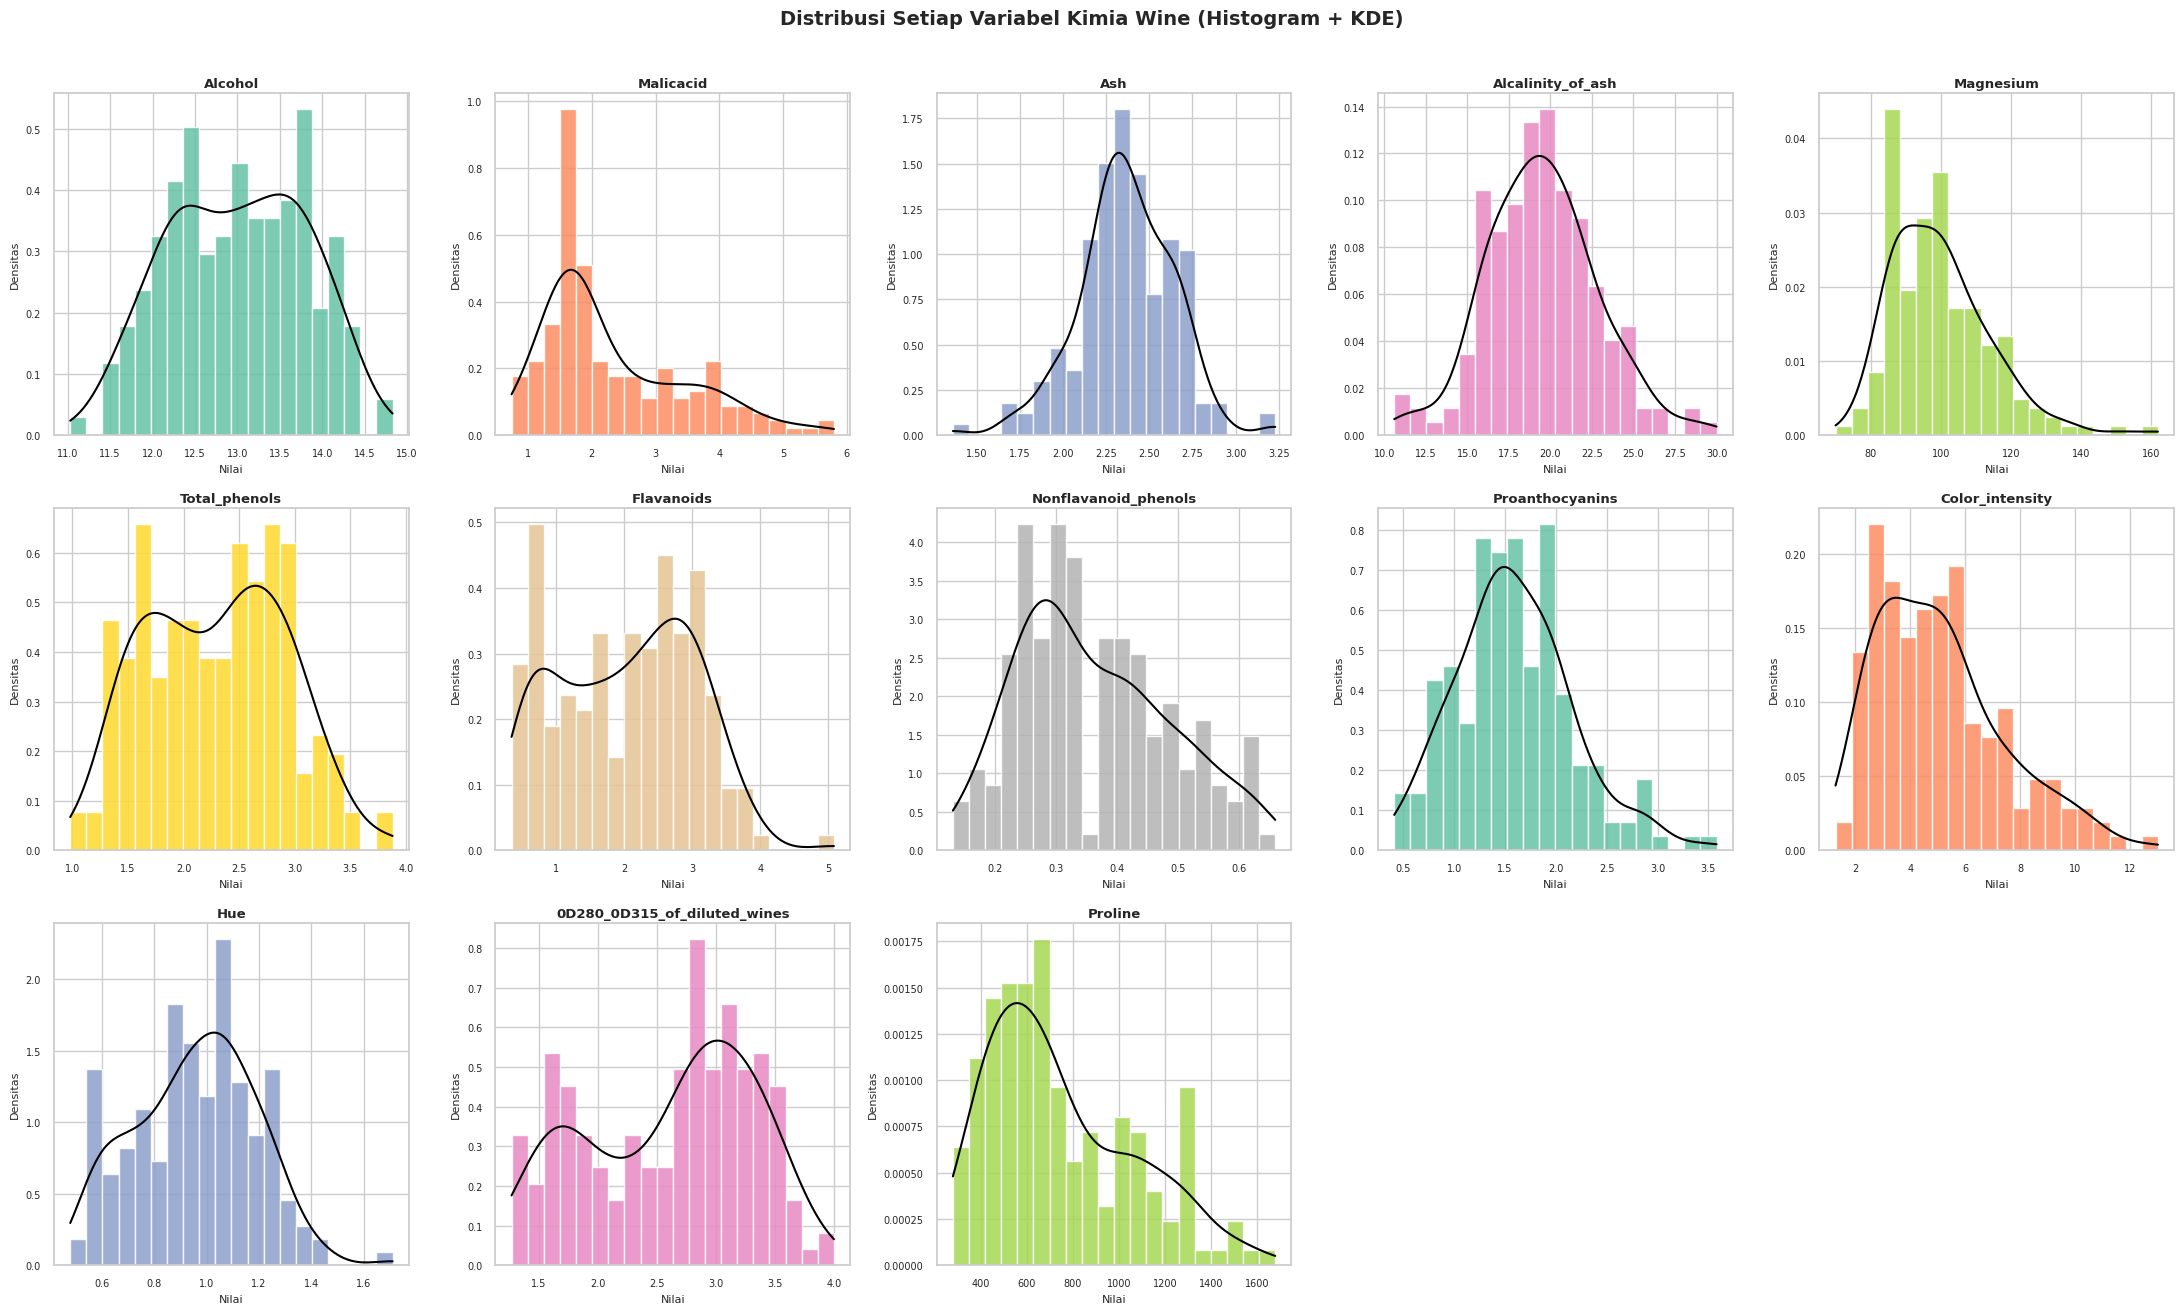

In [ ]:
#---------------------------------------------------
# 4.3 Visualisasi Distribusi Setiap Variabel (Histogram + KDE)
#---------------------------------------------------
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()
colors = plt.cm.Set2.colors

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data_col = df[col].dropna()
    ax.hist(data_col, bins=20, color=colors[i % len(colors)],
            edgecolor='white', alpha=0.85, density=True)
    # KDE overlay
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data_col)
    x_range = np.linspace(data_col.min(), data_col.max(), 200)
    ax.plot(x_range, kde(x_range), color='black', linewidth=1.5)
    ax.set_title(col, fontsize=9.5, fontweight='bold', pad=4)
    ax.set_xlabel('Nilai', fontsize=8)
    ax.set_ylabel('Densitas', fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribusi Setiap Variabel Kimia Wine (Histogram + KDE)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

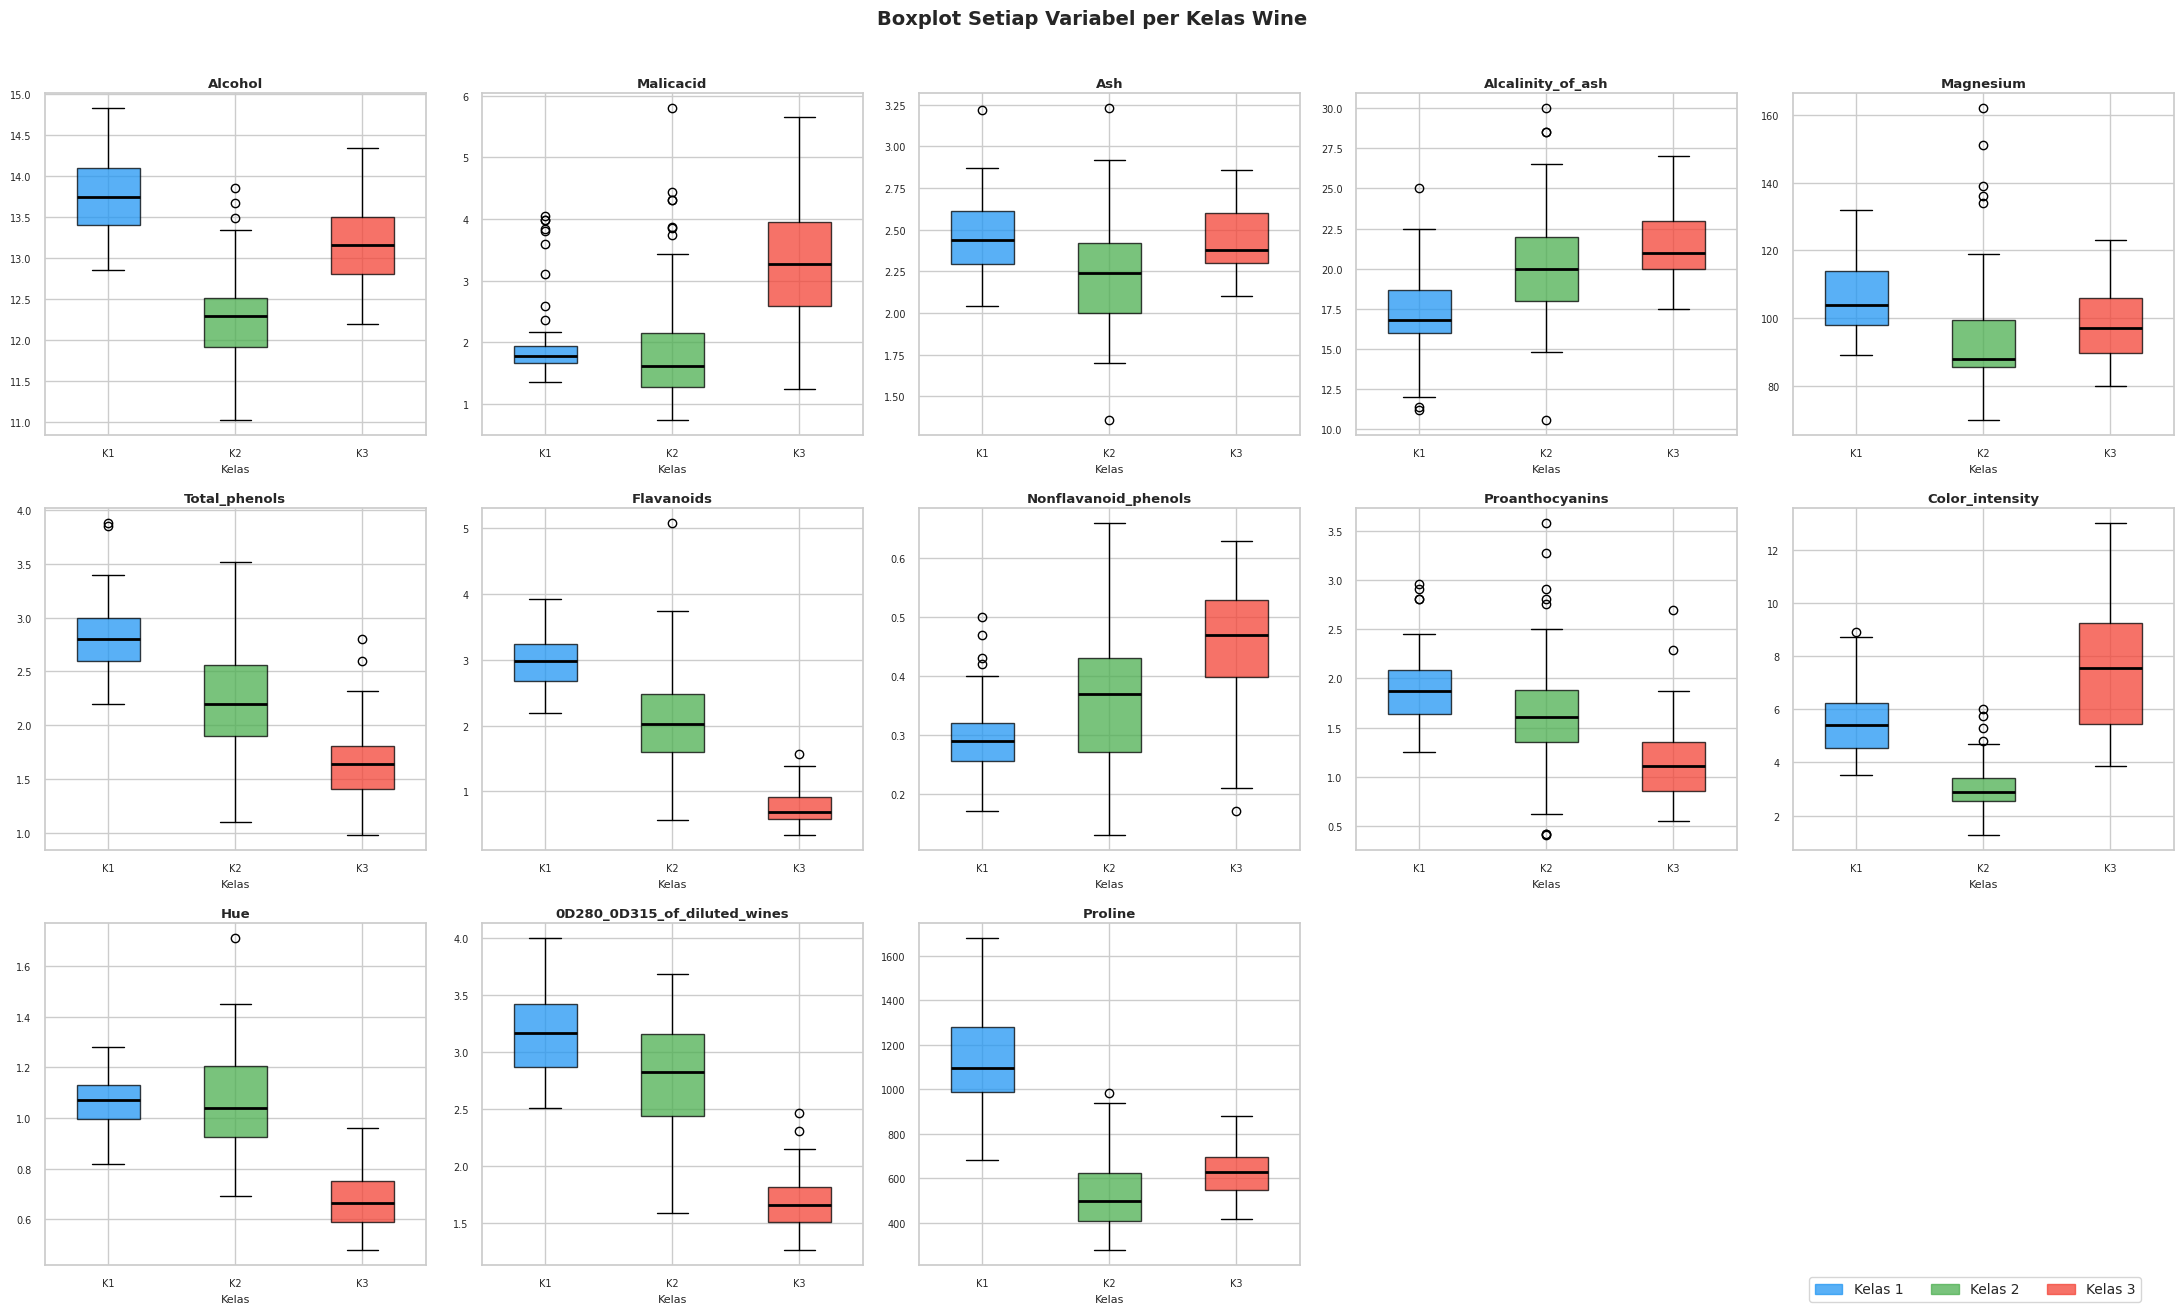

In [ ]:
#---------------------------------------------------
# 4.4 Boxplot per Kelas Wine
#---------------------------------------------------
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()
palette = {1: '#2196F3', 2: '#4CAF50', 3: '#F44336'}

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data_plot = [df[df['class'] == cls][col].values for cls in [1, 2, 3]]
    bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], palette.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(['K1', 'K2', 'K3'])
    ax.set_title(col, fontsize=9.5, fontweight='bold', pad=4)
    ax.set_xlabel('Kelas', fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=f'Kelas {k}', alpha=0.75)
                  for k, c in palette.items()]
fig.legend(handles=legend_patches, loc='lower right',
           fontsize=10, ncol=3, bbox_to_anchor=(0.98, 0.01))
fig.suptitle('Boxplot Setiap Variabel per Kelas Wine',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

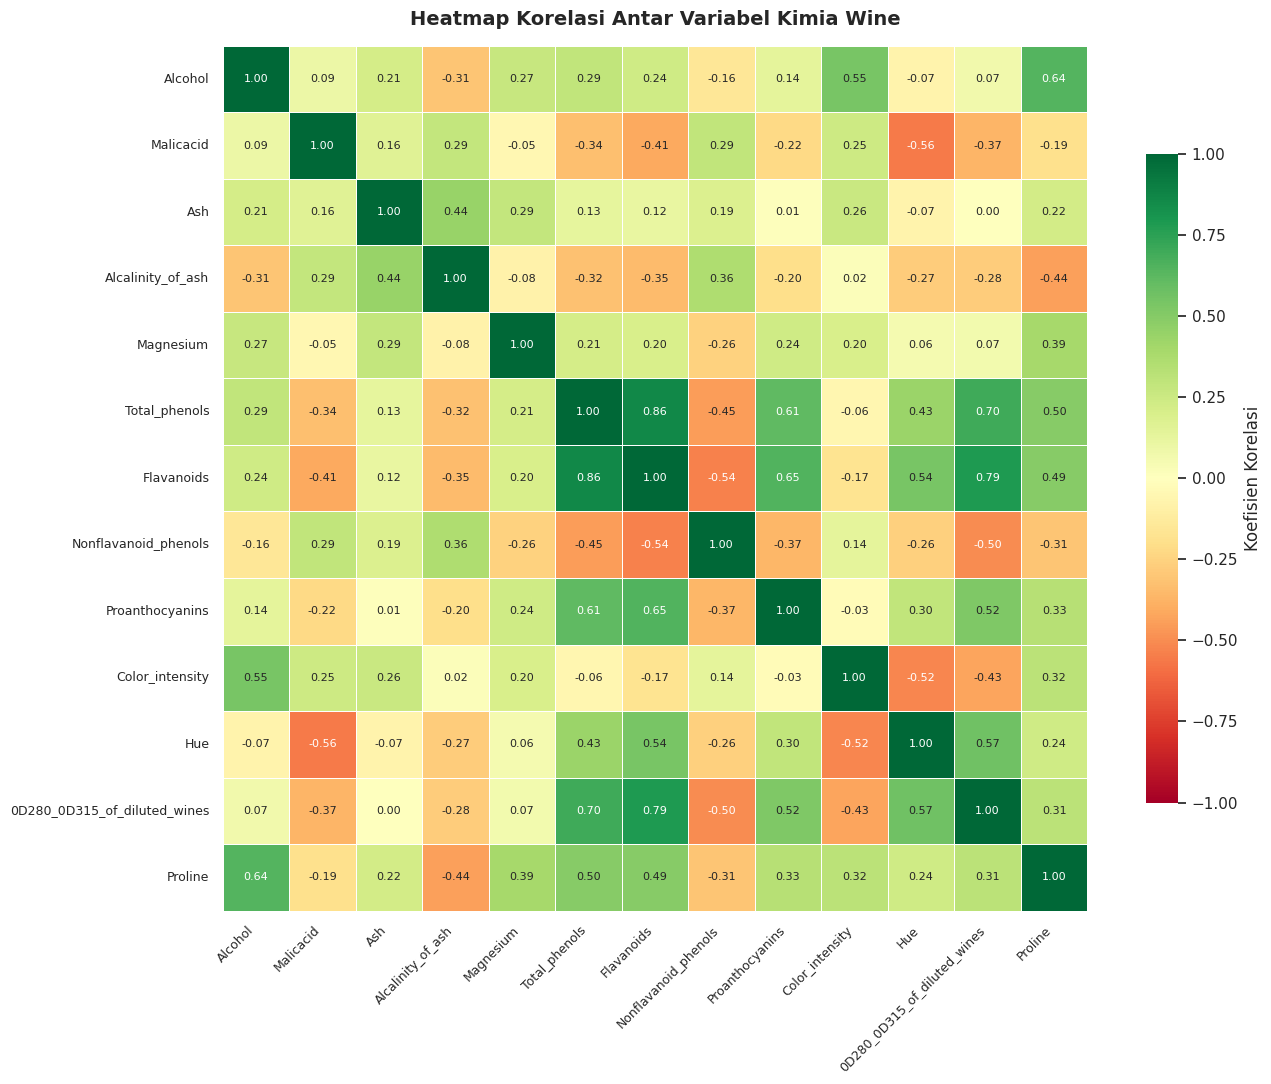

In [ ]:
#---------------------------------------------------
# 4.5 Heatmap Korelasi Antar Variabel
#---------------------------------------------------
corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.4, linecolor='white',
            cbar_kws={'shrink': 0.75, 'label': 'Koefisien Korelasi'},
            annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Variabel Kimia Wine',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

5 variabel dengan korelasi rata-rata tertinggi: ['Flavanoids', 'Total_phenols', '0D280_0D315_of_diluted_wines', 'Proline', 'Hue']


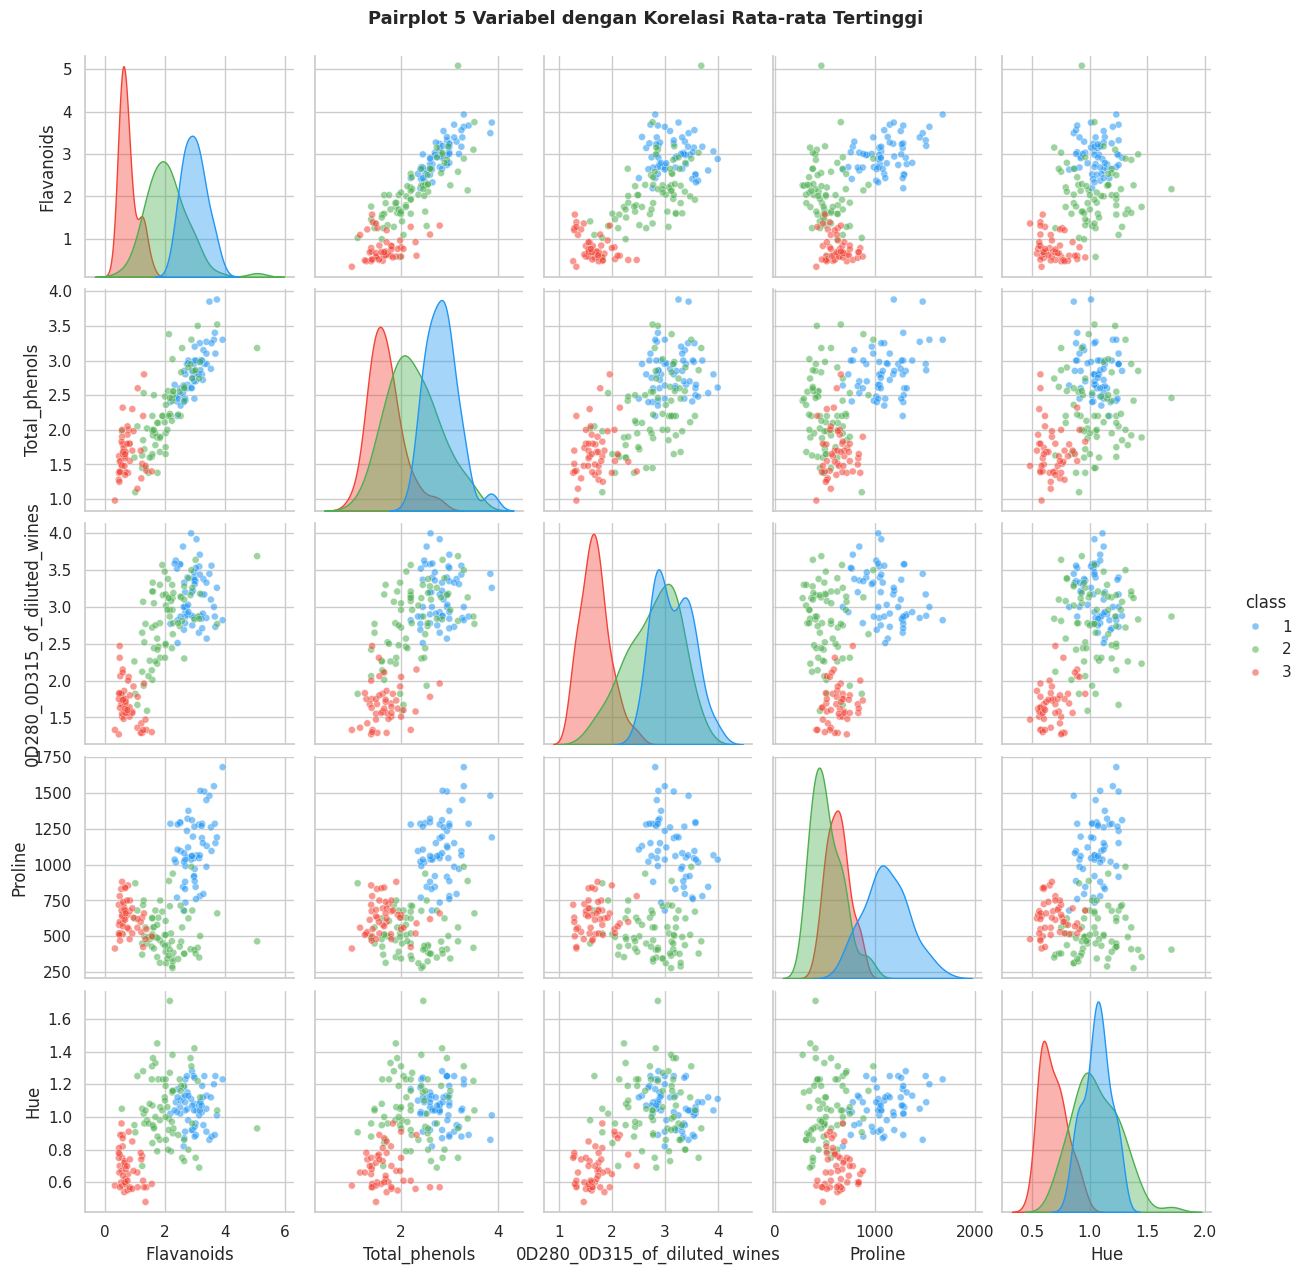

In [ ]:
#---------------------------------------------------
# 4.6 Pairplot (Scatter Matrix)
#---------------------------------------------------
# Pilih 5 variabel dengan rata-rata korelasi absolut tertinggi
corr_temp = df[feature_cols].corr().abs()
mean_corr = corr_temp.mean().sort_values(ascending=False)
selected_vars = mean_corr.head(5).index.tolist()
print(f"5 variabel dengan korelasi rata-rata tertinggi: {selected_vars}")

pairplot_df = df[selected_vars + ['class']].copy()
pairplot_df['class'] = pairplot_df['class'].astype(str)

g = sns.pairplot(pairplot_df, hue='class',
                 palette={'1': '#2196F3', '2': '#4CAF50', '3': '#F44336'},
                 diag_kind='kde', plot_kws={'alpha': 0.55, 's': 25},
                 diag_kws={'fill': True, 'alpha': 0.4})
g.fig.suptitle('Pairplot 5 Variabel dengan Korelasi Rata-rata Tertinggi',
               y=1.02, fontsize=13, fontweight='bold')
plt.show()

IDENTIFIKASI OUTLIER AWAL (METODE IQR):


,Variabel,Q1,Q3,IQR,Lower Fence,Upper Fence,Jumlah Outlier
4,Magnesium,88.0000,107.0000,19.0000,59.5000,135.5000,4
3,Alcalinity_of_ash,17.2000,21.5000,4.3000,10.7500,27.9500,4
9,Color_intensity,3.2200,6.2000,2.9800,-1.2500,10.6700,4
1,Malicacid,1.6020,3.0820,1.4800,-0.6170,5.3020,3
2,Ash,2.2100,2.5580,0.3480,1.6890,3.0790,3
8,Proanthocyanins,1.2500,1.9500,0.7000,0.2000,3.0000,2
10,Hue,0.7820,1.1200,0.3380,0.2760,1.6260,1
0,Alcohol,12.3620,13.6780,1.3150,10.3900,15.6500,0
5,Total_phenols,1.7420,2.8000,1.0570,0.1560,4.3860,0
7,Nonflavanoid_phenols,0.2700,0.4380,0.1670,0.0190,0.6890,0


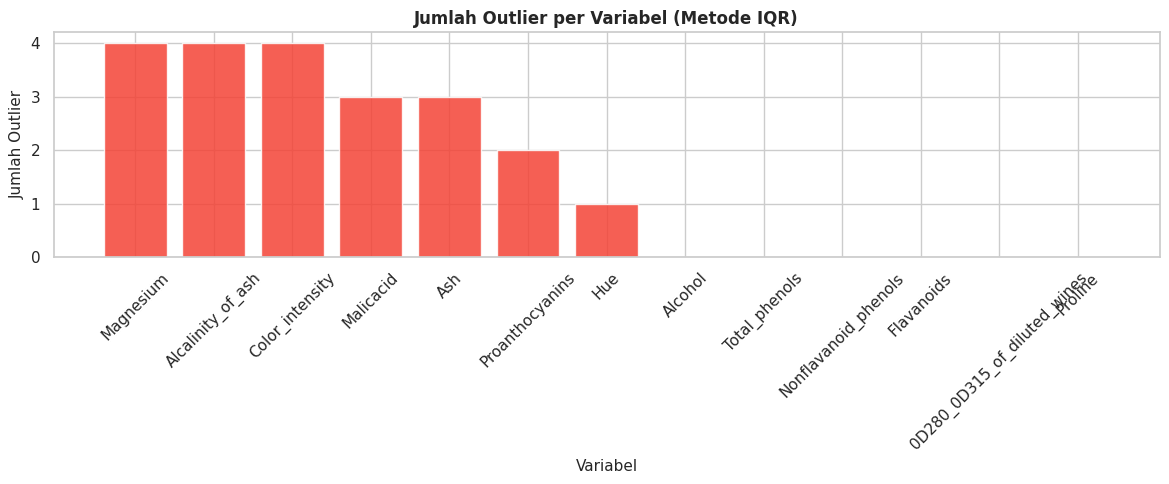

In [ ]:
#---------------------------------------------------
# 4.7 Identifikasi Outlier Awal (Metode IQR)
#---------------------------------------------------
outlier_summary = []
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Variabel': col, 'Q1': round(Q1, 3), 'Q3': round(Q3, 3),
        'IQR': round(IQR, 3), 'Lower Fence': round(lower, 3),
        'Upper Fence': round(upper, 3), 'Jumlah Outlier': n_out
    })

outlier_df = pd.DataFrame(outlier_summary)
print("IDENTIFIKASI OUTLIER AWAL (METODE IQR):")
display(outlier_df.sort_values('Jumlah Outlier', ascending=False))

# Visualisasi menggunakab outlier_df_sorted agar urutan bar konsisten dengan tabel
outlier_df_sorted = outlier_df.sort_values('Jumlah Outlier', ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = ['#F44336' if v > 0 else '#4CAF50' for v in outlier_df_sorted['Jumlah Outlier']]
ax.bar(outlier_df_sorted['Variabel'], outlier_df_sorted['Jumlah Outlier'],
       color=colors_bar, edgecolor='white', alpha=0.85)
ax.set_xlabel('Variabel', fontsize=11)
ax.set_ylabel('Jumlah Outlier', fontsize=11)
ax.set_title('Jumlah Outlier per Variabel (Metode IQR)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Statistik Deskriptif:**  
Nilai rata-rata dan standar deviasi antar variabel terlihat berbeda-beda. Variabel Proline memiliki rentang nilai paling besar dibanding variabel lain, sedangkan beberapa variabel menunjukkan distribusi nilai yang agak miring/skewness.

**Missing Value:**  
Tidak ditemukan missing value pada dataset. Seluruh 178 data lengkap sehingga dapat langsung digunakan untuk analisis.

**Histogram + KDE:**  
Distribusi tiap variabel tidak sepenuhnya sama. Beberapa variabel terlihat mendekati normal, sementara lainnya tampak skew atau memiliki lebih dari satu puncak distribusi.

**Boxplot per Kelas Wine:**  
Beberapa variabel menunjukkan perbedaan distribusi yang cukup jelas antar kelas wine. Selain itu, masih terlihat beberapa titik ekstrem pada sebagian variabel.

**Heatmap Korelasi:**  
Terdapat beberapa pasangan variabel dengan korelasi tinggi, terutama pada Flavanoids, Total_phenols, dan OD280/OD315_of_diluted_wines.

**Pairplot (Scatter Matrix):**  
Beberapa kombinasi variabel memperlihatkan pemisahan kelas wine yang cukup jelas, meskipun masih ada area yang saling tumpang tindih.

**Identifikasi Outlier (Metode IQR):**  
Metode IQR mendeteksi beberapa outlier pada sejumlah variabel. Namun jumlahnya tidak terlalu banyak dibanding keseluruhan data.

---

## **`[5]` Mean Vector & Covariance Matrix**

In [ ]:
# ==============================
# 5. MEAN VECTOR & COVARIANCE MATRIX
# ==============================
#---------------------------------------------------
# 5.1 Mean Vector
#---------------------------------------------------
# Mean vector keseluruhan
overall_mean = df[feature_cols].mean()

print("MEAN VECTOR KESELURUHAN (µ):")
mean_df = pd.DataFrame({'Variabel': feature_cols,
                        'Mean': overall_mean.values.round(4)})
display(mean_df)

print("\nMEAN VECTOR PER KELAS:")
mean_per_class = df.groupby('class')[feature_cols].mean().round(4)
display(mean_per_class)

MEAN VECTOR KESELURUHAN (µ):


,Variabel,Mean
0,Alcohol,13.0006
1,Malicacid,2.3363
2,Ash,2.3665
3,Alcalinity_of_ash,19.4949
4,Magnesium,99.7416
5,Total_phenols,2.2951
6,Flavanoids,2.0293
7,Nonflavanoid_phenols,0.3619
8,Proanthocyanins,1.5909
9,Color_intensity,5.0581



MEAN VECTOR PER KELAS:


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
class,,,,,,,,,,,,,
1,13.7447,2.0107,2.4556,17.0373,106.3390,2.8402,2.9824,0.2900,1.8993,5.5283,1.0620,3.1578,1115.7119
2,12.2787,1.9327,2.2448,20.2380,94.5493,2.2589,2.0808,0.3637,1.6303,3.0866,1.0563,2.7854,519.5070
3,13.1538,3.3338,2.4371,21.4167,99.3125,1.6788,0.7815,0.4475,1.1535,7.3962,0.6827,1.6835,629.8958


In [ ]:
#---------------------------------------------------
# 5.2 Matriks Kovarian
#---------------------------------------------------
cov_matrix = df[feature_cols].cov()

print("MATRIKS KOVARIAN (S):")
display(cov_matrix.round(4))

print("\nVARIANS PER VARIABEL (diagonal matriks kovarian):")
var_df = pd.DataFrame({
    'Variabel': feature_cols,
    'Varians': np.diag(cov_matrix).round(4),
    'Std Dev': np.sqrt(np.diag(cov_matrix)).round(4)
}).sort_values('Varians', ascending=False)
display(var_df)

MATRIKS KOVARIAN (S):


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
Alcohol,0.6591,0.0856,0.0471,-0.8411,3.1399,0.1469,0.1920,-0.0158,0.0635,1.0283,-0.0133,0.0417,164.5672
Malicacid,0.0856,1.2480,0.0503,1.0763,-0.8708,-0.2343,-0.4586,0.0407,-0.1411,0.6448,-0.1433,-0.2924,-67.5489
Ash,0.0471,0.0503,0.0753,0.4062,1.1229,0.0221,0.0315,0.0064,0.0015,0.1647,-0.0047,0.0008,19.3197
Alcalinity_of_ash,-0.8411,1.0763,0.4062,11.1527,-3.9748,-0.6711,-1.1721,0.1504,-0.3772,0.1450,-0.2091,-0.6562,-463.3553
Magnesium,3.1399,-0.8708,1.1229,-3.9748,203.9893,1.9165,2.7931,-0.4556,1.9328,6.6205,0.1809,0.6693,1769.1587
Total_phenols,0.1469,-0.2343,0.0221,-0.6711,1.9165,0.3917,0.5405,-0.0350,0.2194,-0.0800,0.0620,0.3110,98.1711
Flavanoids,0.1920,-0.4586,0.0315,-1.1721,2.7931,0.5405,0.9977,-0.0669,0.3731,-0.3992,0.1241,0.5583,155.4475
Nonflavanoid_phenols,-0.0158,0.0407,0.0064,0.1504,-0.4556,-0.0350,-0.0669,0.0155,-0.0261,0.0401,-0.0075,-0.0445,-12.2036
Proanthocyanins,0.0635,-0.1411,0.0015,-0.3772,1.9328,0.2194,0.3731,-0.0261,0.3276,-0.0335,0.0387,0.2109,59.5543
Color_intensity,1.0283,0.6448,0.1647,0.1450,6.6205,-0.0800,-0.3992,0.0401,-0.0335,5.3744,-0.2765,-0.7058,230.7675



VARIANS PER VARIABEL (diagonal matriks kovarian):


,Variabel,Varians,Std Dev
12,Proline,99166.7174,314.9075
4,Magnesium,203.9893,14.2825
3,Alcalinity_of_ash,11.1527,3.3396
9,Color_intensity,5.3744,2.3183
1,Malicacid,1.2480,1.1171
6,Flavanoids,0.9977,0.9989
0,Alcohol,0.6591,0.8118
11,0D280_0D315_of_diluted_wines,0.5041,0.7100
5,Total_phenols,0.3917,0.6259
8,Proanthocyanins,0.3276,0.5724


In [ ]:
#---------------------------------------------------
# 5.3 Matriks Korelasi
#---------------------------------------------------
corr_full = df[feature_cols].corr()

print("MATRIKS KORELASI (R):")
display(corr_full.round(4))

# Pasangan dengan korelasi kuat
print("\n\nPASANGAN VARIABEL DENGAN KORELASI KUAT (|r| > 0.60):")
strong_corr = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        r = corr_full.iloc[i, j]
        if abs(r) > 0.60:
            strong_corr.append({
                'Variabel 1'   : feature_cols[i],
                'Variabel 2'   : feature_cols[j],
                'Korelasi (r)' : round(r, 4),
                'Arah'         : '↑ Positif' if r > 0 else '↓ Negatif'
            })
sc_df = pd.DataFrame(strong_corr).sort_values('Korelasi (r)', key=abs, ascending=False)
display(sc_df)

MATRIKS KORELASI (R):


,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,0D280_0D315_of_diluted_wines,Proline
Alcohol,1.0000,0.0944,0.2115,-0.3102,0.2708,0.2891,0.2368,-0.1559,0.1367,0.5464,-0.0717,0.0723,0.6437
Malicacid,0.0944,1.0000,0.1640,0.2885,-0.0546,-0.3352,-0.4110,0.2930,-0.2207,0.2490,-0.5613,-0.3687,-0.1920
Ash,0.2115,0.1640,1.0000,0.4434,0.2866,0.1290,0.1151,0.1862,0.0097,0.2589,-0.0747,0.0039,0.2236
Alcalinity_of_ash,-0.3102,0.2885,0.4434,1.0000,-0.0833,-0.3211,-0.3514,0.3619,-0.1973,0.0187,-0.2740,-0.2768,-0.4406
Magnesium,0.2708,-0.0546,0.2866,-0.0833,1.0000,0.2144,0.1958,-0.2563,0.2364,0.2000,0.0554,0.0660,0.3934
Total_phenols,0.2891,-0.3352,0.1290,-0.3211,0.2144,1.0000,0.8646,-0.4499,0.6124,-0.0551,0.4337,0.6999,0.4981
Flavanoids,0.2368,-0.4110,0.1151,-0.3514,0.1958,0.8646,1.0000,-0.5379,0.6527,-0.1724,0.5435,0.7872,0.4942
Nonflavanoid_phenols,-0.1559,0.2930,0.1862,0.3619,-0.2563,-0.4499,-0.5379,1.0000,-0.3658,0.1391,-0.2626,-0.5033,-0.3114
Proanthocyanins,0.1367,-0.2207,0.0097,-0.1973,0.2364,0.6124,0.6527,-0.3658,1.0000,-0.0252,0.2955,0.5191,0.3304
Color_intensity,0.5464,0.2490,0.2589,0.0187,0.2000,-0.0551,-0.1724,0.1391,-0.0252,1.0000,-0.5218,-0.4288,0.3161




PASANGAN VARIABEL DENGAN KORELASI KUAT (|r| > 0.60):


,Variabel 1,Variabel 2,Korelasi (r),Arah
1,Total_phenols,Flavanoids,0.8646,↑ Positif
5,Flavanoids,0D280_0D315_of_diluted_wines,0.7872,↑ Positif
3,Total_phenols,0D280_0D315_of_diluted_wines,0.6999,↑ Positif
4,Flavanoids,Proanthocyanins,0.6527,↑ Positif
0,Alcohol,Proline,0.6437,↑ Positif
2,Total_phenols,Proanthocyanins,0.6124,↑ Positif


**Mean Vector:**  
Rata-rata tiap variabel menunjukkan bahwa ketiga kelas wine memiliki karakteristik kimia yang berbeda. Misalnya, kelas 1 cenderung memiliki nilai Alcohol dan Proline lebih tinggi dibanding kelas lainnya.

**Variabel dengan Varians Terbesar:**  
Variabel Proline memiliki varians paling besar dibanding variabel lain. Hal ini menunjukkan bahwa nilai Proline antar sampel cukup beragam, sedangkan variabel lain seperti Ash dan Nonflavanoid_phenols cenderung lebih stabil.

**Hubungan Antar Variabel (Matriks Korelasi):**  
Flavanoids, Total_phenols, dan OD280/OD315_of_diluted_wines memiliki korelasi positif yang cukup kuat. Selain itu, Color_intensity juga terlihat memiliki hubungan positif dengan Alcohol (meski kurang kuat). Banyaknya korelasi yang cukup tinggi menunjukkan bahwa beberapa variabel saling berkaitan.

---

## **`[6]` Multivariate Normality Test**

In [ ]:
# ==============================
# 6. MULTIVARIATE NORMALITY TEST
# ==============================
#---------------------------------------------------
# 6.1 Menghitung Mahalanobis Distance
#---------------------------------------------------
def hitung_mahalanobis(data):
    """Menghitung Mahalanobis Distance untuk setiap observasi."""
    mean_vec = np.mean(data, axis=0)
    cov_mat  = np.cov(data, rowvar=False)
    cov_inv  = np.linalg.inv(cov_mat)
    diff     = data - mean_vec
    D2 = np.array([diff[i] @ cov_inv @ diff[i] for i in range(len(diff))])
    return D2

X_arr = df[feature_cols].values
D2    = hitung_mahalanobis(X_arr)
df['Mahalanobis_D2'] = D2

p = len(feature_cols)
n = len(df)

print(f"Jumlah variabel (p) : {p}")
print(f"Jumlah observasi (n): {n}")
print(f"\n5 Nilai Mahalanobis D² Terbesar:")
top5_idx = np.argsort(D2)[-5:][::-1]
for idx in top5_idx:
    print(f"  Obs {idx:3d} | Kelas {int(df['class'].iloc[idx])} | D² = {D2[idx]:.4f}")

Jumlah variabel (p) : 13
Jumlah observasi (n): 178

5 Nilai Mahalanobis D² Terbesar:
  Obs 121 | Kelas 2 | D² = 58.6533
  Obs  69 | Kelas 2 | D² = 38.6908
  Obs  95 | Kelas 2 | D² = 38.2263
  Obs  73 | Kelas 2 | D² = 37.9716
  Obs 158 | Kelas 3 | D² = 36.5479


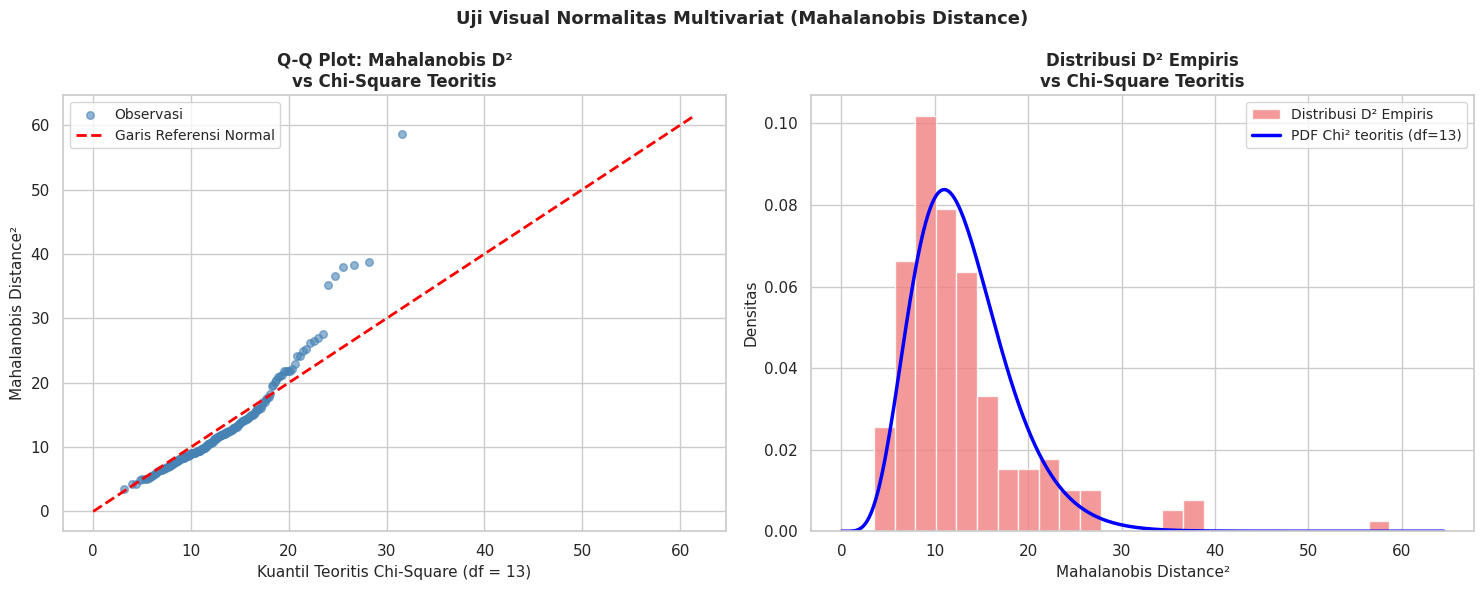

In [ ]:
#---------------------------------------------------
# 6.2 Q-Q Plot Mahalanobis Distance² vs Chi-Square
#---------------------------------------------------
D2_sorted  = np.sort(D2)
quantiles  = (np.arange(1, n + 1) - 0.5) / n
chi2_quant = chi2.ppf(quantiles, df=p)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Q-Q Plot
axes[0].scatter(chi2_quant, D2_sorted, alpha=0.6, color='steelblue', s=30, label='Observasi')
max_val = max(chi2_quant.max(), D2_sorted.max()) * 1.05
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Garis Referensi Normal')
axes[0].set_xlabel(f'Kuantil Teoritis Chi-Square (df = {p})', fontsize=11)
axes[0].set_ylabel('Mahalanobis Distance²', fontsize=11)
axes[0].set_title('Q-Q Plot: Mahalanobis D²\nvs Chi-Square Teoritis', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Histogram D² vs Chi² PDF
x_range = np.linspace(0, D2_sorted.max() * 1.1, 300)
axes[1].hist(D2_sorted, bins=25, density=True, color='lightcoral',
             edgecolor='white', alpha=0.8, label='Distribusi D² Empiris')
axes[1].plot(x_range, chi2.pdf(x_range, df=p), 'b-', linewidth=2.5,
             label=f'PDF Chi² teoritis (df={p})')
axes[1].set_xlabel('Mahalanobis Distance²', fontsize=11)
axes[1].set_ylabel('Densitas', fontsize=11)
axes[1].set_title('Distribusi D² Empiris\nvs Chi-Square Teoritis', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

fig.suptitle('Uji Visual Normalitas Multivariat (Mahalanobis Distance)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#---------------------------------------------------
# 6.3 Uji Normalitas Multivariat (Henze-Zirkler Test)
#---------------------------------------------------
print("=" * 55)
print("UJI NORMALITAS MULTIVARIAT (HENZE-ZIRKLER TEST)")
print("=" * 55)
print(f"Tingkat Signifikansi: α = 0.05\n")

result_hz = pg.multivariate_normality(df[feature_cols], alpha=0.05)

print(f"  Henze-Zirkler Statistic (HZ) : {result_hz.hz:.4f}")
print(f"  P-value                      : {result_hz.pval:.6f}")
print(f"  Normal (H₀ diterima?)        : {result_hz.normal}")
print()
if result_hz.normal:
    print("H₀ GAGAL DITOLAK → Data MEMENUHI asumsi normalitas multivariat.")
else:
    print("H₀ DITOLAK → Data TIDAK MEMENUHI asumsi normalitas multivariat pada α = 0.05.")

UJI NORMALITAS MULTIVARIAT (HENZE-ZIRKLER TEST)
Tingkat Signifikansi: α = 0.05

  Henze-Zirkler Statistic (HZ) : 1.0743
  P-value                      : 0.000000
  Normal (H₀ diterima?)        : False

H₀ DITOLAK → Data TIDAK MEMENUHI asumsi normalitas multivariat pada α = 0.05.


**Mahalanobis Distance & Q-Q Plot:**  
Pada Q-Q Plot, sebagian titik mengikuti garis diagonal, tetapi masih terdapat beberapa penyimpangan terutama di bagian atas. Hal ini menunjukkan bahwa distribusi data tidak sepenuhnya mengikuti normalitas multivariat.

**Hasil Henze-Zirkler Test:**  
Hasil Henze-Zirkler Test menghasilkan p-value < 0.05, sehingga asumsi normalitas multivariat tidak terpenuhi. Kemungkinan hal ini dipengaruhi oleh perbedaan distribusi antar kelas wine dan adanya beberapa outlier.

**Implikasi Praktis:**  
Meskipun asumsi normalitas multivariat tidak terpenuhi, analisis masih dapat dilanjutkan karena ukuran sampel cukup besar. Metode seperti MANOVA dan Hotelling T^2 juga relatif cukup robust terhadap pelanggaran normalitas ringan.

---

## **`[7]` Multivariate Outlier Detection**

In [ ]:
# ==============================
# 7. MULTIVARIATE OUTLIER DETECTION
# ==============================
#---------------------------------------------------
# 7.1 Deteksi Outlier dengan Mahalanobis Distance
#---------------------------------------------------
threshold = chi2.ppf(0.975, p)
df['is_outlier'] = df['Mahalanobis_D2'] > threshold

n_outlier = df['is_outlier'].sum()
n_normal  = (~df['is_outlier']).sum()

print("=" * 55)
print("DETEKSI OUTLIER MULTIVARIAT")
print("=" * 55)
print(f"Jumlah variabel (p)               : {p}")
print(f"Threshold Chi² (df={p}, α=0.025)   : {threshold:.4f}")
print(f"Jumlah observasi total            : {n}")
print(f"Jumlah OUTLIER multivariat        : {n_outlier} ({100*n_outlier/n:.2f}%)")
print(f"Jumlah observasi NORMAL           : {n_normal}  ({100*n_normal/n:.2f}%)")

print("\nDETAIL OUTLIER MULTIVARIAT:")
outlier_detail = df[df['is_outlier']][['class', 'Mahalanobis_D2']].copy()
outlier_detail = outlier_detail.sort_values('Mahalanobis_D2', ascending=False)
display(outlier_detail)

DETEKSI OUTLIER MULTIVARIAT
Jumlah variabel (p)               : 13
Threshold Chi² (df=13, α=0.025)   : 24.7356
Jumlah observasi total            : 178
Jumlah OUTLIER multivariat        : 12 (6.74%)
Jumlah observasi NORMAL           : 166  (93.26%)

DETAIL OUTLIER MULTIVARIAT:


,class,Mahalanobis_D2
121,2,58.6533
69,2,38.6908
95,2,38.2263
73,2,37.9716
158,3,36.5479
110,2,35.1739
59,2,27.6290
115,2,26.9483
71,2,26.5353
159,3,26.1418


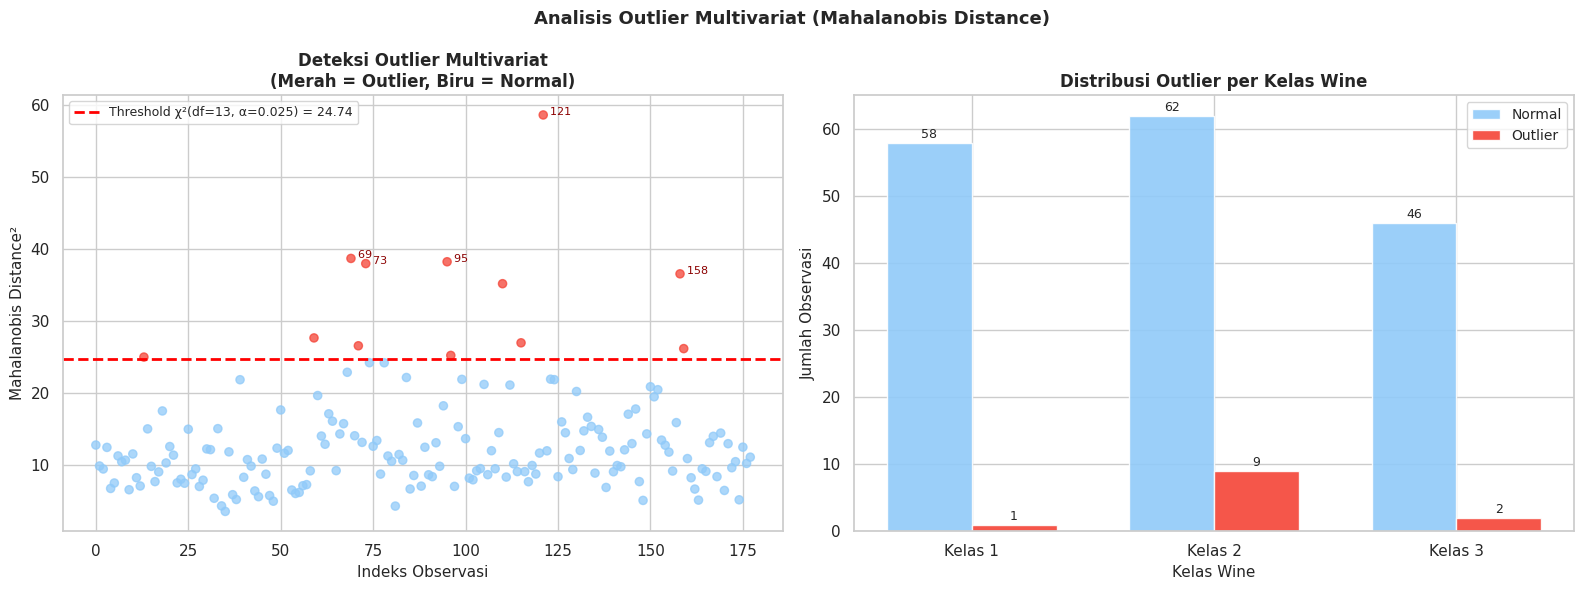

In [ ]:
#---------------------------------------------------
# 7.2 Visualisasi Outlier Multivariat
#---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scatter Mahalanobis D² per indeks
colors_pt = ['#F44336' if x else '#90CAF9' for x in df['is_outlier']]
axes[0].scatter(range(n), df['Mahalanobis_D2'], c=colors_pt, s=35, alpha=0.75)
axes[0].axhline(y=threshold, color='red', linestyle='--', linewidth=2,
                label=f'Threshold χ²(df={p}, α=0.025) = {threshold:.2f}')

# Beri label pada outlier teratas
top_outliers = df[df['is_outlier']].nlargest(5, 'Mahalanobis_D2')
for idx in top_outliers.index:
    axes[0].annotate(f'  {idx}', (idx, df.loc[idx, 'Mahalanobis_D2']),
                     fontsize=8, color='darkred')

axes[0].set_xlabel('Indeks Observasi', fontsize=11)
axes[0].set_ylabel('Mahalanobis Distance²', fontsize=11)
axes[0].set_title('Deteksi Outlier Multivariat\n(Merah = Outlier, Biru = Normal)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Plot 2: Jumlah outlier per kelas
classes = [1, 2, 3]
n_out_cls    = [df[(df['class']==c) & (df['is_outlier'])].shape[0] for c in classes]
n_normal_cls = [df[(df['class']==c) & (~df['is_outlier'])].shape[0] for c in classes]
x_pos  = np.array([1, 2, 3])
width  = 0.35
bars1 = axes[1].bar(x_pos - width/2, n_normal_cls, width, label='Normal',
                     color='#90CAF9', edgecolor='white', alpha=0.9)
bars2 = axes[1].bar(x_pos + width/2, n_out_cls, width, label='Outlier',
                     color='#F44336', edgecolor='white', alpha=0.9)

# Label nilai di atas bar
for bar in bars1 + bars2:
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                     str(int(h)), ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Kelas 1', 'Kelas 2', 'Kelas 3'])
axes[1].set_xlabel('Kelas Wine', fontsize=11)
axes[1].set_ylabel('Jumlah Observasi', fontsize=11)
axes[1].set_title('Distribusi Outlier per Kelas Wine', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

fig.suptitle('Analisis Outlier Multivariat (Mahalanobis Distance)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Metode Mahalanobis Distance:**  
Deteksi menggunakan Mahalanobis Distance menunjukkan adanya beberapa observasi dengan nilai D^2 yang melebihi batas kritis Chi-Square. Observasi tersebut dikategorikan sebagai outlier multivariat karena memiliki kombinasi karakteristik yang cukup berbeda dari mayoritas data.

**Perbedaan dengan Outlier Univariat:**  
Outlier univariat terlihat ekstrem pada satu variabel, sedangkan outlier multivariat baru tampak berbeda ketika beberapa variabel dianalisis secara bersamaan.

**Pengaruh terhadap Analisis:**  
Outlier multivariat dapat memengaruhi estimasi mean vector dan matriks kovarian. Namun, karena jumlah outlier relatif sedikit dibanding total data, analisis lanjutan masih dapat dilakukan.

---

## **`[8]` Hotelling T-Square Test**

In [ ]:
# ==============================
# 8. HOTELLING T-SQUARE TEST
# ==============================
#---------------------------------------------------
# 8.1 Persiapan Data: Kelas 1 vs 2, Kelas 1 vs 3, Kelas 2 vs 3
#---------------------------------------------------
from itertools import combinations

pasangan = list(combinations([1, 2, 3], 2))
data_kelas = {cls: df[df['class'] == cls][feature_cols].values for cls in [1, 2, 3]}

n1 = len(data_kelas[1])
n2 = len(data_kelas[2])
n3 = len(data_kelas[3])

print("=" * 60)
print("  UJI HOTELLING T² DUA SAMPEL UNTUK SEMUA PASANGAN KELAS")
print("=" * 60)
print(f"  Jumlah variabel (p) : {len(feature_cols)}")
print(f"  n₁ (Kelas 1)        : {n1} observasi")
print(f"  n₂ (Kelas 2)        : {n2} observasi")
print(f"  n₃ (Kelas 3)        : {n3} observasi")
print()
print("HIPOTESIS (berlaku untuk setiap pasangan):")
print("  H₀ : µᵢ = µⱼ  (mean vector kedua kelas identik)")
print("  H₁ : µᵢ ≠ µⱼ  (terdapat perbedaan mean vector)")
print("  α  = 0.05")

  UJI HOTELLING T² DUA SAMPEL UNTUK SEMUA PASANGAN KELAS
  Jumlah variabel (p) : 13
  n₁ (Kelas 1)        : 59 observasi
  n₂ (Kelas 2)        : 71 observasi
  n₃ (Kelas 3)        : 48 observasi

HIPOTESIS (berlaku untuk setiap pasangan):
  H₀ : µᵢ = µⱼ  (mean vector kedua kelas identik)
  H₁ : µᵢ ≠ µⱼ  (terdapat perbedaan mean vector)
  α  = 0.05


In [ ]:
#---------------------------------------------------
# 8.2 Hasil Uji Hotelling T² Semua Pasangan
#---------------------------------------------------
hasil_t2 = []

for (c1, c2) in pasangan:
    res = pg.multivariate_ttest(data_kelas[c1], data_kelas[c2], paired=False)
    T2    = float(res['T2'].values[0])
    F_val = float(res['F'].values[0])
    pval  = float(res['pval'].values[0])
    hasil_t2.append({
        'Pasangan'   : f'Kelas {c1} vs Kelas {c2}',
        'T²'         : round(T2, 4),
        'F-statistic': round(F_val, 4),
        'p-value'    : pval,
        'Keputusan'  : 'H₀ Ditolak ✗' if pval < 0.05 else 'H₀ Gagal Ditolak ✓'
    })
    print(f"Kelas {c1} vs Kelas {c2}:")
    print(f"  T² = {T2:.4f} | F = {F_val:.4f} | p-value = {pval:.2e}")
    print(f"  → {'H₀ DITOLAK karena perbedaan yang signifikan' if pval < 0.05 else 'H₀ GAGAL DITOLAK'}")
    print()

Kelas 1 vs Kelas 2:
  T² = 799.6552 | F = 55.7452 | p-value = 1.35e-43
  → H₀ DITOLAK karena perbedaan yang signifikan

Kelas 1 vs Kelas 3:
  T² = 3075.7414 | F = 209.5560 | p-value = 8.15e-63
  → H₀ DITOLAK karena perbedaan yang signifikan

Kelas 2 vs Kelas 3:
  T² = 800.2966 | F = 55.2473 | p-value = 7.46e-41
  → H₀ DITOLAK karena perbedaan yang signifikan



In [ ]:
#---------------------------------------------------
# 8.3 Tabel Ringkasan Perbandingan 3 Pasangan
#---------------------------------------------------
ringkasan_t2 = pd.DataFrame(hasil_t2)
print("TABEL RINGKASAN HOTELLING T² UNTUK SEMUA PASANGAN:")
display(ringkasan_t2.style.applymap(
    lambda v: 'color: red; font-weight: bold' if 'Gagal' not in str(v) and 'Ditolak' in str(v) else '',
    subset=['Keputusan']
))

TABEL RINGKASAN HOTELLING T² UNTUK SEMUA PASANGAN:


,Pasangan,T²,F-statistic,p-value,Keputusan
0,Kelas 1 vs Kelas 2,799.655200,55.745200,0.000000,H₀ Ditolak ✗
1,Kelas 1 vs Kelas 3,3075.741400,209.556000,0.000000,H₀ Ditolak ✗
2,Kelas 2 vs Kelas 3,800.296600,55.247300,0.000000,H₀ Ditolak ✗


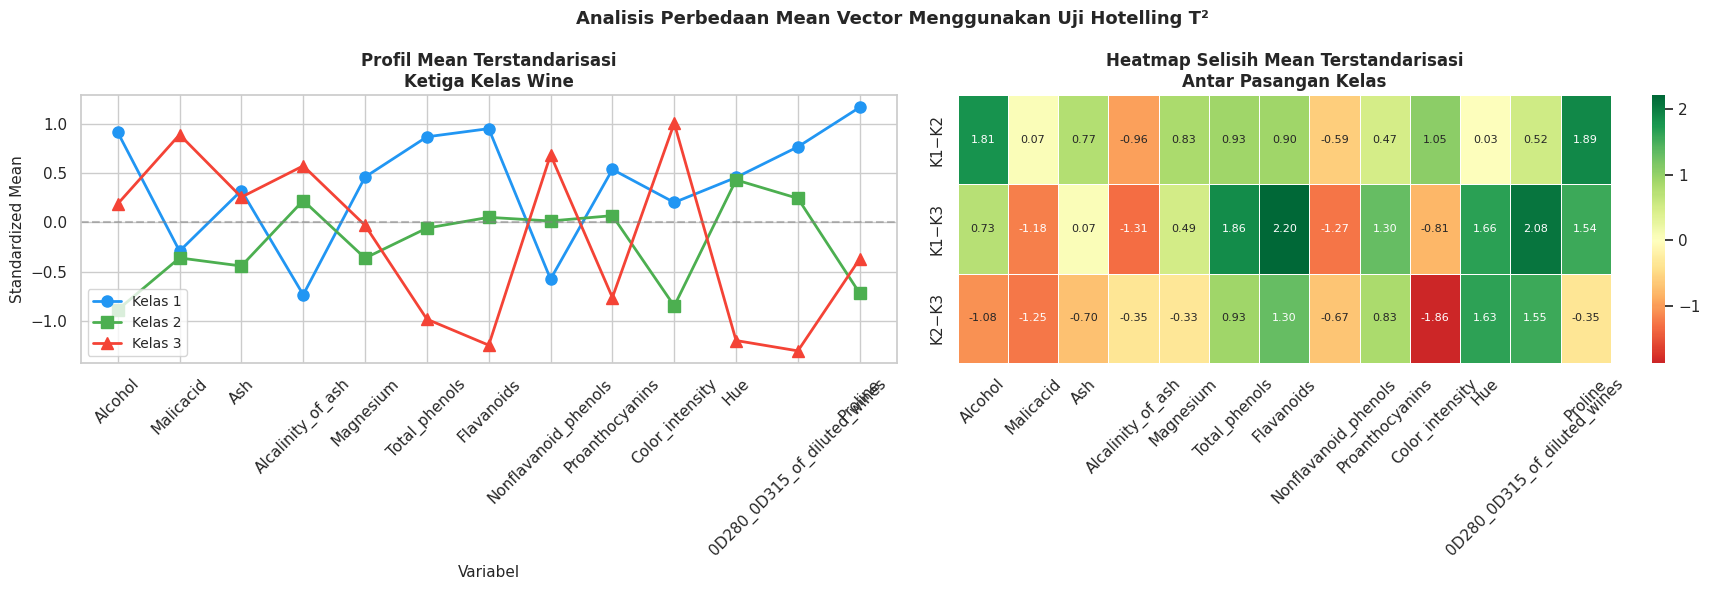

In [ ]:
#---------------------------------------------------
# 8.4 Visualisasi Mean Vector Ketiga Kelas
#---------------------------------------------------
means = {cls: pd.Series(data_kelas[cls].mean(axis=0), index=feature_cols)
         for cls in [1, 2, 3]}
std_all = df[feature_cols].std()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
palette = {1: '#2196F3', 2: '#4CAF50', 3: '#F44336'}
markers = {1: 'o', 2: 's', 3: '^'}

# Profil mean terstandarisasi ketiga kelas
for cls in [1, 2, 3]:
    mean_std = (means[cls] - df[feature_cols].mean()) / std_all
    axes[0].plot(feature_cols, mean_std.values,
                 marker=markers[cls], linewidth=2, markersize=8,
                 color=palette[cls], label=f'Kelas {cls}')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Variabel', fontsize=11)
axes[0].set_ylabel('Standardized Mean', fontsize=11)
axes[0].set_title('Profil Mean Terstandarisasi\nKetiga Kelas Wine', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# Heatmap perbedaan mean antar pasangan
diff_matrix = pd.DataFrame(index=feature_cols)
for (c1, c2) in pasangan:
    diff_std = (means[c1] - means[c2]) / std_all
    diff_matrix[f'K{c1}−K{c2}'] = diff_std.values

sns.heatmap(diff_matrix.T, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[1], annot_kws={'size': 8})
axes[1].set_title('Heatmap Selisih Mean Terstandarisasi\nAntar Pasangan Kelas', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Analisis Perbedaan Mean Vector Menggunakan Uji Hotelling T²',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Hasil Uji Hotelling T²:**  
Seluruh pasangan kelas menghasilkan p-value < 0.05, sehingga H₀ ditolak untuk semua pasangan. Hasil ini menunjukkan bahwa setiap kelas wine memiliki mean vector yang berbeda secara signifikan.

**Perbedaan Antar Kelas:**  
Nilai T² yang lebih besar menunjukkan perbedaan karakteristik kimia yang semakin kuat antar pasangan kelas wine. Dari heatmap selisih mean terstandarisasi, variabel Flavanoids, OD280/OD315, dan Total_phenols secara konsisten menunjukkan selisih terbesar di semua pasangan kelas sehingga menegaskan bahwa ketiga variabel ini adalah pembeda paling kuat antar cultivar wine.

---

## **`[9]` Homogenity Covariance Test**

In [ ]:
# ==============================
# 9. HOMOGENEITY COVARIANCE TEST
# ==============================
#---------------------------------------------------
# 9.1 Box's M Test
#---------------------------------------------------
# Cek nama kolom yang tersedia
print("Kolom tersedia di df:", list(df.columns))
print()

# dep_vars didefinisikan karena Box's M Test harus menguji variabel yang sama dengan
# MANOVA (karena keduanya harus konsisten agar asumsi yang diperiksa relevan)
dep_vars = feature_cols[:7]
print(f"Variabel dependen: {dep_vars}")

boxm_vars = dep_vars

print("=" * 60)
print("  UJI HOMOGENITAS MATRIKS KOVARIAN MENGGUNAKAN BOX'S M TEST")
print("=" * 60)
print(f"  Variabel yang diuji: {boxm_vars}")
print(f"  Kelompok           : Kelas 1, 2, 3")
print()
print("HIPOTESIS:")
print("  H₀ : Σ₁ = Σ₂ = Σ₃  (matriks kovarian semua kelas identik/homogen)")
print("  H₁ : Minimal satu Σᵢ berbeda  (terdapat heterogenitas kovarian)")
print(f"  α  = 0.05")
print()

boxm_result = pg.box_m(data=df, dvs=boxm_vars, group='class')
print("HASIL BOX'S M TEST:")
display(boxm_result)

chi2_stat = float(boxm_result['Chi2'].values[0])
df_val    = float(boxm_result['df'].values[0])
pval_boxm = float(boxm_result['pval'].values[0])

print(f"\nRINGKASAN:")
print(f"  Chi-Square Statistic : {chi2_stat:.4f}")
print(f"  Degrees of Freedom   : {df_val:.0f}")
print(f"  P-value              : {pval_boxm:.6f}")
print()
print("KEPUTUSAN:")
if pval_boxm < 0.05:
    print(f"  → Karena p-value ({pval_boxm:.2e}) < α (0.05), H₀ DITOLAK.")
    print("  → Matriks kovarian antar kelas wine TIDAK HOMOGEN.")
else:
    print(f"  → Karena p-value ({pval_boxm:.4f}) ≥ α (0.05), H₀ GAGAL DITOLAK.")
    print("  → Matriks kovarian antar kelas wine HOMOGEN.")

Kolom tersedia di df: ['class', 'Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue', '0D280_0D315_of_diluted_wines', 'Proline', 'Mahalanobis_D2', 'is_outlier']

Variabel dependen: ['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids']
  UJI HOMOGENITAS MATRIKS KOVARIAN MENGGUNAKAN BOX'S M TEST
  Variabel yang diuji: ['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids']
  Kelompok           : Kelas 1, 2, 3

HIPOTESIS:
  H₀ : Σ₁ = Σ₂ = Σ₃  (matriks kovarian semua kelas identik/homogen)
  H₁ : Minimal satu Σᵢ berbeda  (terdapat heterogenitas kovarian)
  α  = 0.05

HASIL BOX'S M TEST:


,Chi2,df,pval,equal_cov
box,209.9941,56.0000,0.0000,False



RINGKASAN:
  Chi-Square Statistic : 209.9941
  Degrees of Freedom   : 56
  P-value              : 0.000000

KEPUTUSAN:
  → Karena p-value (1.15e-19) < α (0.05), H₀ DITOLAK.
  → Matriks kovarian antar kelas wine TIDAK HOMOGEN.


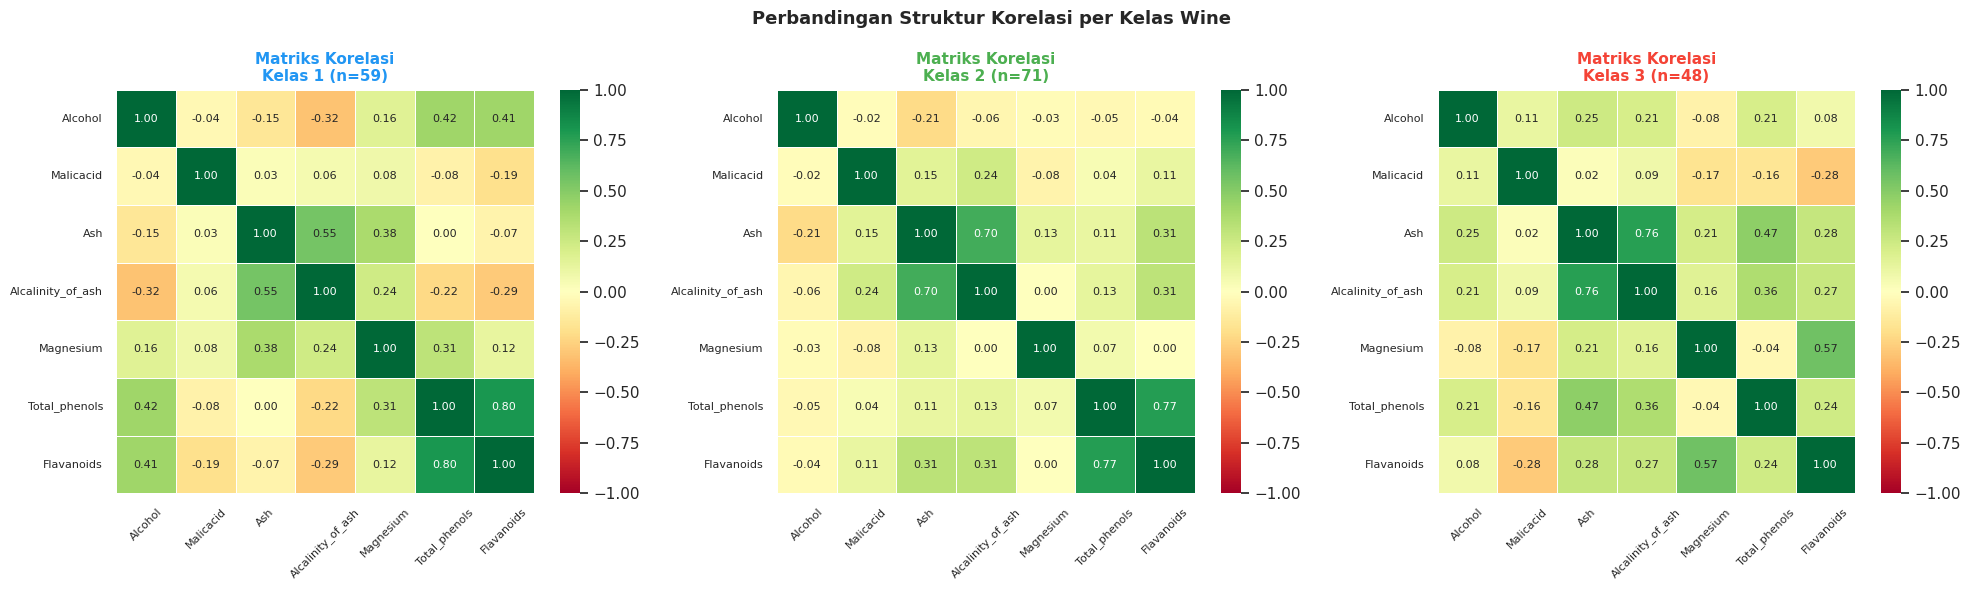

In [ ]:
#---------------------------------------------------
# 9.2 Visualisasi Matriks Korelasi per Kelas
#---------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
palette_cls = ['#2196F3', '#4CAF50', '#F44336']

for i, cls in enumerate([1, 2, 3]):
    cls_data = df[df['class'] == cls][boxm_vars]
    corr_cls = cls_data.corr()
    sns.heatmap(corr_cls, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=-1, vmax=1, center=0, ax=axes[i],
                linewidths=0.5, annot_kws={'size': 8},
                xticklabels=boxm_vars, yticklabels=boxm_vars)
    axes[i].set_title(f'Matriks Korelasi\nKelas {cls} (n={df[df["class"]==cls].shape[0]})',
                      fontsize=11, fontweight='bold', color=palette_cls[i])
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

fig.suptitle('Perbandingan Struktur Korelasi per Kelas Wine',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#---------------------------------------------------
# 9.3 Tabel Ringkasan Pemenuhan Asumsi MANOVA
#---------------------------------------------------
print("TABEL RINGKASAN ASUMSI MANOVA:")

# Ambil nilai dari hasil uji sebelumnya
hz_normal  = result_hz.normal
hz_pval    = result_hz.pval
n_outlier  = int(df['is_outlier'].sum())
pct_outlier = 100 * n_outlier / len(df)

asumsi_data = {
    'Asumsi'         : [
        'Normalitas Multivariat',
        'Homogenitas Matriks Kovarian',
        'Tidak Ada Outlier Ekstrem'
    ],
    'Metode Uji'     : [
        'Henze-Zirkler Test',
        "Box's M Test",
        'Mahalanobis Distance'
    ],
    'Statistik / Info': [
        f'HZ = {result_hz.hz:.4f}, p = {hz_pval:.2e}',
        f'χ² = {chi2_stat:.4f}, p = {pval_boxm:.2e}',
        f'{n_outlier} outlier ({pct_outlier:.1f}%)'
    ],
    'Hasil'          : [
        'Tidak terpenuhi',
        'Tidak terpenuhi',
        'Minimal'
    ],
    'Kesimpulan'     : [
        'n = 178 cukup besar, CLT berlaku',
        'Sampel antar kelas relatif seimbang',
        'Jumlah kecil, tidak mendistorsi hasil'
    ]
}

asumsi_df = pd.DataFrame(asumsi_data)
display(asumsi_df)

TABEL RINGKASAN ASUMSI MANOVA:


,Asumsi,Metode Uji,Statistik / Info,Hasil,Kesimpulan
0,Normalitas Multivariat,Henze-Zirkler Test,"HZ = 1.0743, p = 1.18e-68",Tidak terpenuhi,"n = 178 cukup besar, CLT berlaku"
1,Homogenitas Matriks Kovarian,Box's M Test,"χ² = 209.9941, p = 1.15e-19",Tidak terpenuhi,Sampel antar kelas relatif seimbang
2,Tidak Ada Outlier Ekstrem,Mahalanobis Distance,12 outlier (6.7%),Minimal,"Jumlah kecil, tidak mendistorsi hasil"


**Box's M Test:**  
Hasil Box's M Test menghasilkan p-value < 0.05, sehingga H₀ ditolak. Hal ini menunjukkan bahwa matriks kovarian antar kelas wine tidak sepenuhnya homogen.

**Pola Kovarian Antar Kelas:**  
Perbedaan struktur kovarian juga terlihat dari heatmap korelasi tiap kelas yang menunjukkan pola hubungan antar variabel tidak sama pada semua kelas wine.

**Ringkasan Asumsi MANOVA:**  
Meskipun asumsi normalitas multivariat dan homogenitas kovarian tidak sepenuhnya terpenuhi, analisis MANOVA masih dapat dilakukan karena ukuran sampel cukup besar dan distribusi jumlah data antar kelas relatif seimbang.

---

## **`[10]` MANOVA**

In [ ]:
# ==============================
# 10. MANOVA
# ==============================
#---------------------------------------------------
# 10.1 Persiapan MANOVA
#---------------------------------------------------
print("Semua feature_cols:", feature_cols)
print()

# dep_vars yang sudah didefinisikab di Section 9.1, digunakan kembali untuk uji MANOVA
print(f"Variabel dependen MANOVA: {dep_vars}")

print("=" * 60)
print("  MULTIVARIATE ANALYSIS OF VARIANCE (MANOVA)")
print("=" * 60)
print(f"  Variabel Dependen ({len(dep_vars)} variabel):")
for v in dep_vars:
    print(f"    • {v}")
print(f"\n  Variabel Independen: class (Kelas 1, 2, 3)")

print("\nHIPOTESIS:")
print("  H₀ : µ₁ = µ₂ = µ₃  (mean vector semua kelas identik)")
print("  H₁ : Minimal satu kelas memiliki mean vector berbeda")
print(f"  α  = 0.05")

Semua feature_cols: ['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue', '0D280_0D315_of_diluted_wines', 'Proline']

Variabel dependen MANOVA: ['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids']
  MULTIVARIATE ANALYSIS OF VARIANCE (MANOVA)
  Variabel Dependen (7 variabel):
    • Alcohol
    • Malicacid
    • Ash
    • Alcalinity_of_ash
    • Magnesium
    • Total_phenols
    • Flavanoids

  Variabel Independen: class (Kelas 1, 2, 3)

HIPOTESIS:
  H₀ : µ₁ = µ₂ = µ₃  (mean vector semua kelas identik)
  H₁ : Minimal satu kelas memiliki mean vector berbeda
  α  = 0.05


In [ ]:
#---------------------------------------------------
# 10.2 Menjalankan MANOVA dan Membaca Hasil
#---------------------------------------------------
from statsmodels.multivariate.manova import MANOVA

# Rename sementara: 'class' menjadi 'wine_class', dan semua spasi di nama kolom diganti underscore
df_manova = df.rename(columns={'class': 'wine_class'})
df_manova.columns = df_manova.columns.str.replace(' ', '_').str.replace('/', '_')

# Update dep_vars sesuai nama kolom yang sudah dibersihkan
dep_vars_clean = [c.replace(' ', '_').replace('/', '_') for c in dep_vars]

formula = ' + '.join(dep_vars_clean) + ' ~ wine_class'
print("Formula:", formula)

manova_model  = MANOVA.from_formula(formula, data=df_manova)
manova_result = manova_model.mv_test()

print("HASIL MANOVA:")
print(manova_result)

# Ekstrak Wilks' Lambda
stat_table = manova_result.results['wine_class']['stat']
print("\nTABEL STATISTIK UJI:")
display(stat_table)

wilks_val  = float(stat_table.loc["Wilks' lambda", 'Value'])
wilks_F    = float(stat_table.loc["Wilks' lambda", 'F Value'])
wilks_pval = float(stat_table.loc["Wilks' lambda", 'Pr > F'])

print("\n" + "=" * 55)
print("  RINGKASAN WILKS' LAMBDA")
print("=" * 55)
print(f"  Wilks' Lambda (Λ) : {wilks_val:.6f}")
print(f"  F-statistic       : {wilks_F:.4f}")
print(f"  P-value           : {wilks_pval:.2e}")
print(f"  α                 : 0.05")
print()
print("KEPUTUSAN:")
if wilks_pval < 0.05:
    print(f"  → Karena p-value ({wilks_pval:.2e}) < α (0.05), H₀ DITOLAK.")
    print("  → Terdapat perbedaan yang SANGAT SIGNIFIKAN pada mean vector")
    print("    karakteristik kimia antara ketiga kelas wine.")
else:
    print(f"  → Karena p-value ({wilks_pval:.4f}) ≥ α (0.05), H₀ GAGAL DITOLAK.")
    print("  → Tidak ada perbedaan signifikan antar kelas wine.")

Formula: Alcohol + Malicacid + Ash + Alcalinity_of_ash + Magnesium + Total_phenols + Flavanoids ~ wine_class
HASIL MANOVA:
                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda  0.0148 7.0000 170.0000 1615.9431 0.0000
         Pillai's trace  0.9852 7.0000 170.0000 1615.9431 0.0000
 Hotelling-Lawley trace 66.5388 7.0000 170.0000 1615.9431 0.0000
    Roy's greatest root 66.5388 7.0000 170.0000 1615.9431 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
          wine_class       Value  Num DF  Den DF  F Value Pr > F
----------------------------------------------------

,Value,Num DF,Den DF,F Value,Pr > F
Wilks' lambda,0.2067,7,170.0000,93.2129,0.0000
Pillai's trace,0.7933,7.0000,170.0000,93.2129,0.0000
Hotelling-Lawley trace,3.8382,7,170.0000,93.2129,0.0000
Roy's greatest root,3.8382,7,170,93.2129,0.0000



  RINGKASAN WILKS' LAMBDA
  Wilks' Lambda (Λ) : 0.206689
  F-statistic       : 93.2129
  P-value           : 7.55e-55
  α                 : 0.05

KEPUTUSAN:
  → Karena p-value (7.55e-55) < α (0.05), H₀ DITOLAK.
  → Terdapat perbedaan yang SANGAT SIGNIFIKAN pada mean vector
    karakteristik kimia antara ketiga kelas wine.


In [ ]:
#---------------------------------------------------
# 10.3 Partial Eta Squared (η²)
#---------------------------------------------------
print("=" * 55)
print("  PARTIAL ETA SQUARED (η²)")
print("=" * 55)

# Partial η² dari Wilks' Lambda
eta_sq = 1 - wilks_val

# Interpretasi kategori (Cohen's d)
if eta_sq >= 0.14:
    kategori = "Besar (Large)"
elif eta_sq >= 0.06:
    kategori = "Sedang (Medium)"
else:
    kategori = "Kecil (Small)"

print(f"\n  Wilks' Lambda (Λ)    : {wilks_val:.6f}")
print(f"  Partial η²  = 1 − Λ : {eta_sq:.6f}")
print(f"  Kategori Effect Size : {kategori}")
print()
print("  Panduan interpretasi (Cohen's d):")
print("    η² < 0.06  → Kecil  | 0.06–0.14 → Sedang | > 0.14 → Besar")
print()
print(f"  → Variabel kelas wine menjelaskan {eta_sq*100:.2f}% variansi")
print(f"    total pada kombinasi variabel dependen yang diuji.")

  PARTIAL ETA SQUARED (η²)

  Wilks' Lambda (Λ)    : 0.206689
  Partial η²  = 1 − Λ : 0.793311
  Kategori Effect Size : Besar (Large)

  Panduan interpretasi (Cohen's d):
    η² < 0.06  → Kecil  | 0.06–0.14 → Sedang | > 0.14 → Besar

  → Variabel kelas wine menjelaskan 79.33% variansi
    total pada kombinasi variabel dependen yang diuji.


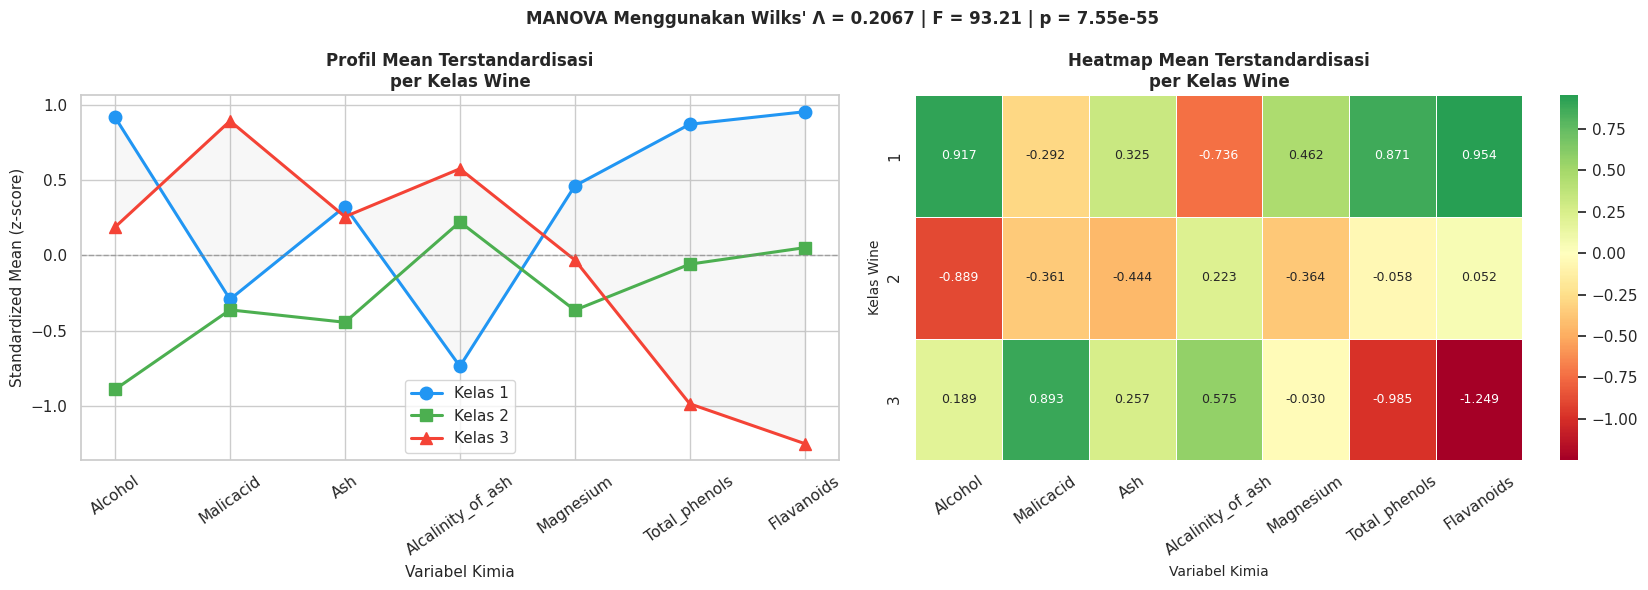

In [ ]:
#---------------------------------------------------
# 10.4 Visualisasi Profil Mean Terstandardisasi per Kelas
#---------------------------------------------------
mean_cls  = df.groupby('class')[dep_vars].mean()
std_all   = df[dep_vars].std()
mean_std  = (mean_cls - df[dep_vars].mean()) / std_all

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
palette   = {1: '#2196F3', 2: '#4CAF50', 3: '#F44336'}
markers   = {1: 'o', 2: 's', 3: '^'}

# Profil plot
for cls in [1, 2, 3]:
    axes[0].plot(dep_vars, mean_std.loc[cls].values,
                 marker=markers[cls], linewidth=2.2, markersize=9,
                 color=palette[cls], label=f'Kelas {cls}')
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[0].fill_between(dep_vars,
                     mean_std.loc[1].values, mean_std.loc[3].values,
                     alpha=0.06, color='gray')
axes[0].set_xlabel('Variabel Kimia', fontsize=11)
axes[0].set_ylabel('Standardized Mean (z-score)', fontsize=11)
axes[0].set_title('Profil Mean Terstandardisasi\nper Kelas Wine', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].tick_params(axis='x', rotation=35)

# Heatmap
sns.heatmap(mean_std, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[1],
            annot_kws={'size': 9})
axes[1].set_title('Heatmap Mean Terstandardisasi\nper Kelas Wine', fontweight='bold')
axes[1].set_xlabel('Variabel Kimia', fontsize=10)
axes[1].set_ylabel('Kelas Wine', fontsize=10)
axes[1].tick_params(axis='x', rotation=35)

try:
    fig.suptitle(f'MANOVA Menggunakan Wilks\' Λ = {wilks_val:.4f} | F = {wilks_F:.2f} | p = {wilks_pval:.2e}',
                 fontsize=12, fontweight='bold')
except:
    fig.suptitle('MANOVA Mengenai Profil Mean Antar Kelas Wine', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

  POST-HOC: ANOVA UNIVARIAT PER VARIABEL DEPENDEN
  (Dilakukan setelah MANOVA signifikan untuk mengidentifikasi
   variabel mana yang paling berkontribusi pada perbedaan)

HASIL ANOVA UNIVARIAT PER VARIABEL (diurutkan berdasarkan η²):


,Variabel,F-statistic,p-value,η²,Signifikan?
6,Flavanoids,233.9259,0.0000,0.7278,Ya
0,Alcohol,135.0776,0.0000,0.6069,Ya
5,Total_phenols,93.7330,0.0000,0.5172,Ya
1,Malicacid,36.9434,0.0000,0.2969,Ya
3,Alcalinity_of_ash,35.7716,0.0000,0.2902,Ya
2,Ash,13.3129,0.0000,0.1321,Ya
4,Magnesium,12.4296,0.0000,0.1244,Ya


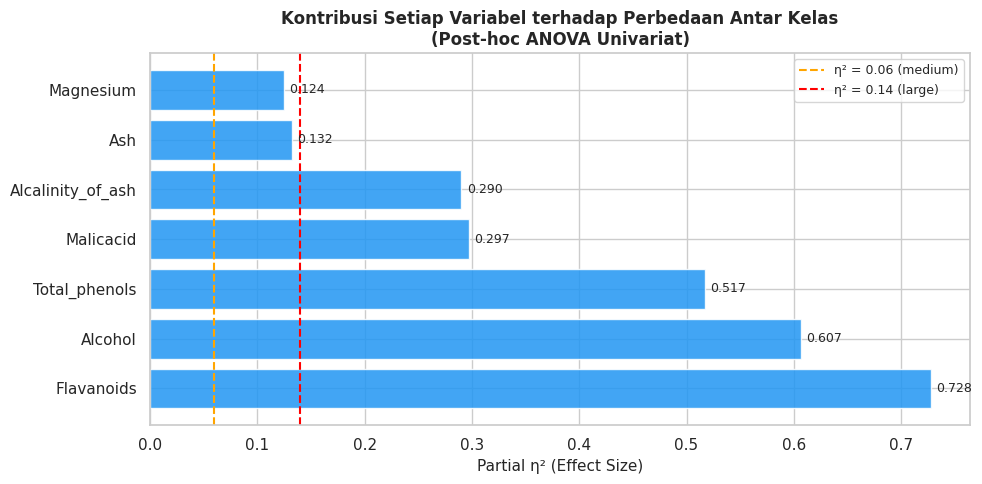

In [ ]:
#---------------------------------------------------
# 10.5 Post-hoc: ANOVA Univariat per Variabel Dependen
#---------------------------------------------------
from scipy.stats import f_oneway

print("=" * 60)
print("  POST-HOC: ANOVA UNIVARIAT PER VARIABEL DEPENDEN")
print("=" * 60)
print("  (Dilakukan setelah MANOVA signifikan untuk mengidentifikasi")
print("   variabel mana yang paling berkontribusi pada perbedaan)")
print()

posthoc_results = []
for var in dep_vars_clean:
    groups = [df_manova[df_manova['wine_class'] == cls][var].values
              for cls in [1, 2, 3]]
    F_val, p_val = f_oneway(*groups)

    # Eta squared univariat
    grand_mean = df_manova[var].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = ((df_manova[var] - grand_mean)**2).sum()
    eta2       = ss_between / ss_total

    posthoc_results.append({
        'Variabel'   : var,
        'F-statistic': round(F_val, 4),
        'p-value'    : round(p_val, 6),
        'η²'         : round(eta2, 4),
        'Signifikan?': 'Ya' if p_val < 0.05 else 'Tidak'
    })

posthoc_df = pd.DataFrame(posthoc_results).sort_values('η²', ascending=False)
print("HASIL ANOVA UNIVARIAT PER VARIABEL (diurutkan berdasarkan η²):")
display(posthoc_df)

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
colors_ph = ['#2196F3' if p < 0.05 else '#BDBDBD'
             for p in posthoc_df['p-value']]
bars = ax.barh(posthoc_df['Variabel'], posthoc_df['η²'],
               color=colors_ph, edgecolor='white', alpha=0.85)
ax.axvline(x=0.06, color='orange', linestyle='--', linewidth=1.5, label='η² = 0.06 (medium)')
ax.axvline(x=0.14, color='red',    linestyle='--', linewidth=1.5, label='η² = 0.14 (large)')
for bar, val in zip(bars, posthoc_df['η²']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Partial η² (Effect Size)', fontsize=11)
ax.set_title('Kontribusi Setiap Variabel terhadap Perbedaan Antar Kelas\n(Post-hoc ANOVA Univariat)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

4 variabel paling diskriminatif (η² tertinggi): ['Flavanoids', 'Alcohol', 'Total_phenols', 'Malicacid']


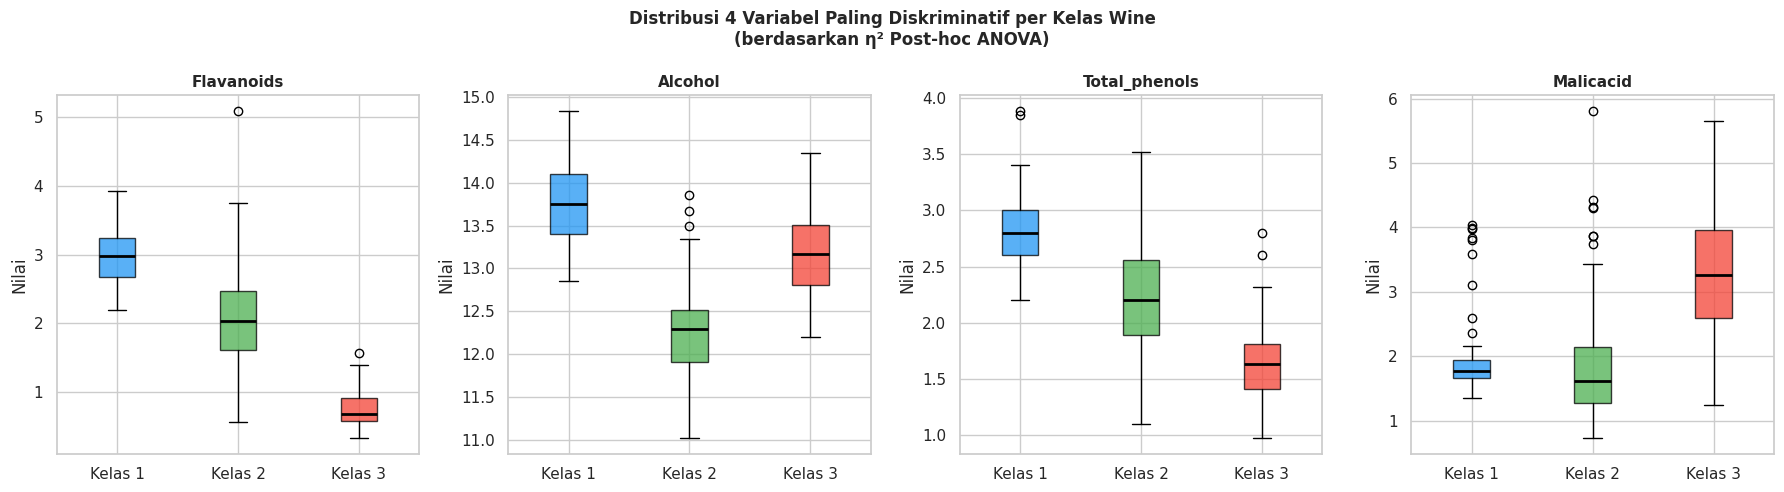

In [ ]:
#---------------------------------------------------
# 10.6 Boxplot Variabel Paling Diskriminatif per Kelas
#---------------------------------------------------
# Ambil 4 variabel dengan η² tertinggi dari hasil post-hoc ANOVA
top_vars = posthoc_df.head(4)['Variabel'].tolist()
print(f"4 variabel paling diskriminatif (η² tertinggi): {top_vars}")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, var in enumerate(top_vars):
    data_plot = [df_manova[df_manova['wine_class'] == cls][var].values
                 for cls in [1, 2, 3]]
    bp = axes[i].boxplot(data_plot, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], palette.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    axes[i].set_xticklabels(['Kelas 1', 'Kelas 2', 'Kelas 3'])
    axes[i].set_title(var, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Nilai')

fig.suptitle('Distribusi 4 Variabel Paling Diskriminatif per Kelas Wine\n(berdasarkan η² Post-hoc ANOVA)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Reduksi Dimensi (PCA)

  PC1 menjelaskan : 36.20% variansi
  PC2 menjelaskan : 19.21% variansi
  Total           : 55.41% variansi


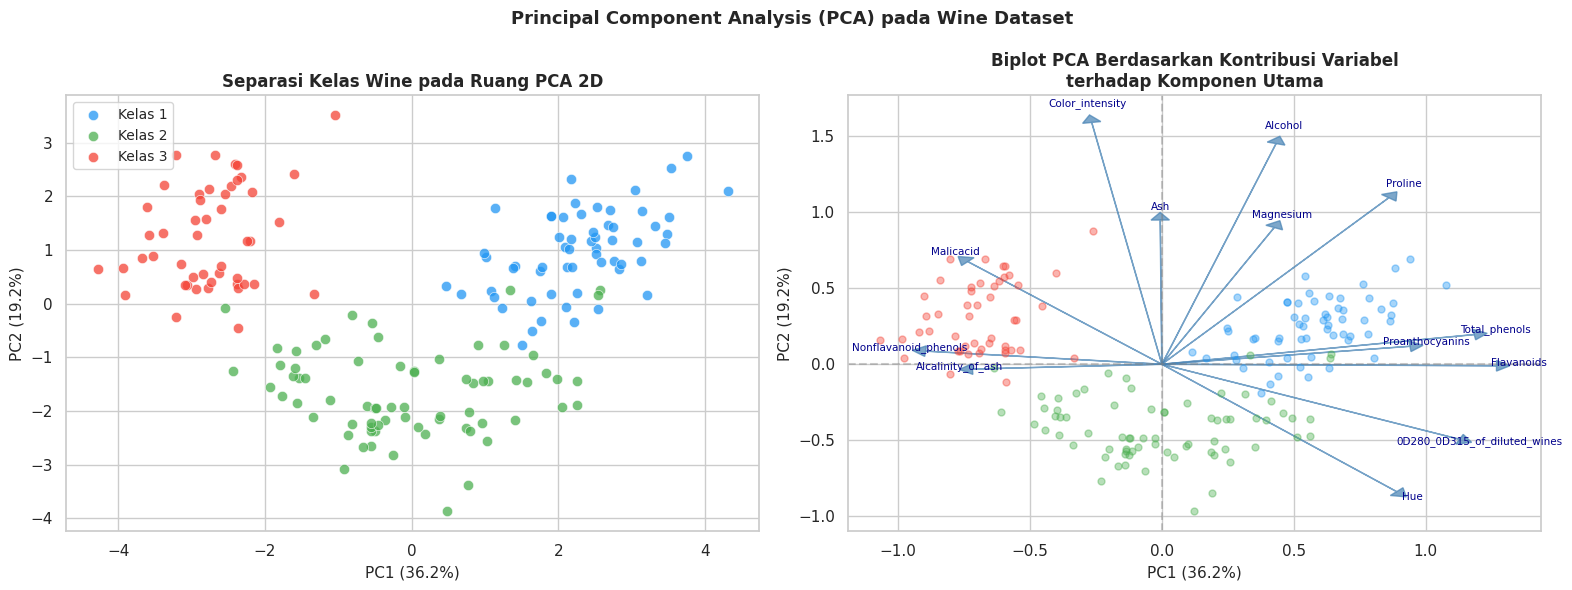

In [ ]:
#---------------------------------------------------
# 10.7 Reduksi Dimensi (PCA)
#---------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Reduksi Dimensi (PCA)")
print()

# Standardisasi dan PCA
scaler  = StandardScaler()
X_std   = scaler.fit_transform(df[feature_cols])
pca     = PCA(n_components=2)
X_pca   = pca.fit_transform(X_std)

var_exp = pca.explained_variance_ratio_
print(f"  PC1 menjelaskan : {var_exp[0]*100:.2f}% variansi")
print(f"  PC2 menjelaskan : {var_exp[1]*100:.2f}% variansi")
print(f"  Total           : {sum(var_exp)*100:.2f}% variansi")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette   = {1: '#2196F3', 2: '#4CAF50', 3: '#F44336'}

# Scatter PCA
for cls in [1, 2, 3]:
    idx = df['class'].values == cls
    axes[0].scatter(X_pca[idx, 0], X_pca[idx, 1],
                    c=palette[cls], label=f'Kelas {cls}',
                    s=55, alpha=0.75, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', fontsize=11)
axes[0].set_title('Separasi Kelas Wine pada Ruang PCA 2D', fontweight='bold')
axes[0].legend(fontsize=10)

# Biplot loading
loadings = pca.components_.T
for i, var in enumerate(feature_cols):
    axes[1].arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3,
                  head_width=0.07, head_length=0.05,
                  fc='steelblue', ec='steelblue', alpha=0.7)
    axes[1].text(loadings[i, 0]*3.2, loadings[i, 1]*3.2,
                 var, fontsize=7.5, ha='center', color='darkblue')
for cls in [1, 2, 3]:
    idx = df['class'].values == cls
    axes[1].scatter(X_pca[idx, 0]/4, X_pca[idx, 1]/4,
                    c=palette[cls], s=25, alpha=0.4)
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('Biplot PCA Berdasarkan Kontribusi Variabel\nterhadap Komponen Utama', fontweight='bold')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.4)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.4)

plt.suptitle('Principal Component Analysis (PCA) pada Wine Dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

LDA (LINEAR DISCRIMINANT ANALYSIS)
Analisis lanjutan untuk menemukan fungsi pembeda optimal

  LD1 menjelaskan : 68.75% variansi antar kelas
  LD2 menjelaskan : 31.25% variansi antar kelas
  Total           : 100.00%

AKURASI KLASIFIKASI (resubstitution):
  Akurasi : 100.00%

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Kelas 1       1.00      1.00      1.00        59
     Kelas 2       1.00      1.00      1.00        71
     Kelas 3       1.00      1.00      1.00        48

    accuracy                           1.00       178
   macro avg       1.00      1.00      1.00       178
weighted avg       1.00      1.00      1.00       178



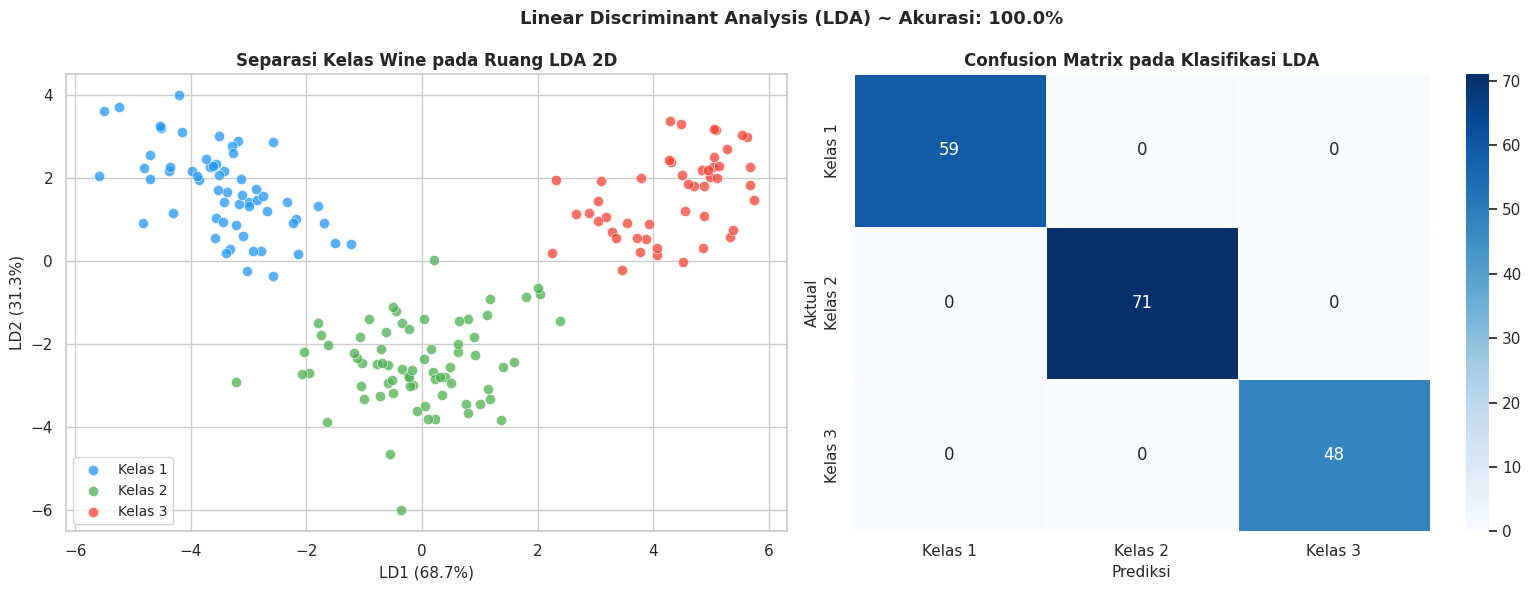

In [ ]:
#---------------------------------------------------
# 10.8 LDA (Linear Discriminant Analysis)
#---------------------------------------------------
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix

print("LDA (LINEAR DISCRIMINANT ANALYSIS)")
print("Analisis lanjutan untuk menemukan fungsi pembeda optimal")
print()

lda     = LinearDiscriminantAnalysis()
X_lda   = lda.fit_transform(X_std, df['class'].values)
y_pred  = lda.predict(X_std)

# Explained variance per LD
ev = lda.explained_variance_ratio_
print(f"  LD1 menjelaskan : {ev[0]*100:.2f}% variansi antar kelas")
print(f"  LD2 menjelaskan : {ev[1]*100:.2f}% variansi antar kelas")
print(f"  Total           : {sum(ev)*100:.2f}%")
print()
print("AKURASI KLASIFIKASI (resubstitution):")
acc = (y_pred == df['class'].values).mean()
print(f"  Akurasi : {acc*100:.2f}%")
print()
print("CLASSIFICATION REPORT:")
print(classification_report(df['class'].values, y_pred,
                             target_names=['Kelas 1','Kelas 2','Kelas 3']))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter LDA
for cls in [1, 2, 3]:
    idx = df['class'].values == cls
    axes[0].scatter(X_lda[idx, 0], X_lda[idx, 1],
                    c=palette[cls], label=f'Kelas {cls}',
                    s=55, alpha=0.75, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'LD1 ({ev[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'LD2 ({ev[1]*100:.1f}%)', fontsize=11)
axes[0].set_title('Separasi Kelas Wine pada Ruang LDA 2D', fontweight='bold')
axes[0].legend(fontsize=10)

# Confusion matrix
cm = confusion_matrix(df['class'].values, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kelas 1','Kelas 2','Kelas 3'],
            yticklabels=['Kelas 1','Kelas 2','Kelas 3'],
            ax=axes[1], linewidths=0.5)
axes[1].set_xlabel('Prediksi', fontsize=11)
axes[1].set_ylabel('Aktual', fontsize=11)
axes[1].set_title('Confusion Matrix pada Klasifikasi LDA', fontweight='bold')

plt.suptitle(f'Linear Discriminant Analysis (LDA) ~ Akurasi: {acc*100:.1f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**P-value:**  
P-value < 0.05 menunjukkan bukti yang sangat kuat untuk menolak H₀. Artinya, perbedaan mean vector karakteristik kimia antar kelas wine adalah nyata dan signifikan secara statistik, bukan karena kebetulan.

**Wilks' Lambda:**  
Wilks' Lambda yang sangat kecil dengan p-value < 0.05 menunjukkan bahwa H₀ ditolak. Artinya, ketiga kelas wine memiliki perbedaan profil kimia secara simultan.

**Effect Size (Partial η²):**  
Nilai partial η² yang tinggi (> 0.14) menunjukkan bahwa perbedaan antar kelas tidak hanya signifikan secara statistik, tetapi juga cukup besar secara praktis.

**Post-hoc ANOVA Univariat:**  
Hasil post-hoc menunjukkan bahwa variabel Flavanoids, Alcohol, dan Total_phenols memiliki kontribusi terbesar dalam membedakan kelas wine, diikuti oleh beberapa variabel lain seperti Proline dan Color_intensity.

**PCA (Visualisasi Separasi):**  
Hasil PCA menunjukkan bahwa ketiga kelas wine dapat terpisah cukup jelas pada dua komponen utama, sehingga perbedaan antar kelas juga terlihat secara visual.

**LDA (Fungsi Pembeda Optimal):**  
LDA menghasilkan pemisahan kelas yang sangat baik dengan akurasi tinggi, menunjukkan bahwa karakteristik kimia wine cukup kuat untuk membedakan jenis wine secara otomatis.

---

## **`[11]` Conclusion**

In [ ]:
# ==============================
# 11. CONCLUSION
# ==============================

# Kesimpulan ditulis dalam format markdown



#### **A. Ringkasan Temuan Seluruh Analisis**

| No | Tahap Analisis         | Metode                    | Temuan Utama                                                                 |
|----|------------------------|---------------------------|------------------------------------------------------------------------------|
| 1  | Data Understanding     | Eksplorasi awal           | 178 observasi, 13 variabel, 3 kelas wine, tanpa missing value                |
| 2  | EDA                    | Deskriptif, heatmap, pairplot | Proline paling bervariasi; Flavanoids dan Total_phenols sangat berkorelasi   |
| 3  | Mean Vector & Kovarian | Statistik multivariat     | Mean vector antar kelas berbeda; Proline memiliki varians terbesar            |
| 4  | Normalitas Multivariat | Henze-Zirkler, Q-Q Plot   | Tidak terpenuhi (p < 0.05), tetapi masih dapat digunakan karena n cukup besar |
| 5  | Outlier Multivariat    | Mahalanobis Distance      | Outlier ada tetapi jumlahnya kecil dan tidak dominan                          |
| 6  | Hotelling T²           | Uji dua sampel            | Semua pasangan kelas berbeda signifikan (p < 0.05)                           |
| 7  | Box's M Test           | Homogenitas kovarian      | Kovarian tidak homogen, namun data tetap seimbang antar kelas                 |
| 8  | MANOVA                 | Wilks' Lambda             | Perbedaan antar kelas signifikan dan kuat (Λ sangat kecil, η² besar)          |
| 9  | Post-hoc ANOVA         | F-test univariat          | Flavanoids, Alcohol, Total_phenols paling membedakan kelas                    |
| 10 | PCA                    | Reduksi dimensi           | Tiga kelas cukup terpisah di ruang 2D                                         |
| 11 | LDA                    | Klasifikasi               | Akurasi sangat tinggi, pemisahan kelas sangat jelas                           |



#### **B. Kesimpulan**

Analisis menunjukkan bahwa asumsi klasik multivariat tidak sepenuhnya terpenuhi, yaitu normalitas multivariat dan homogenitas kovarian. Namun, kondisi ini tidak terlalu mengganggu karena ukuran sampel cukup besar dan distribusi antar kelas relatif seimbang.

Hasil Hotelling T² menunjukkan bahwa seluruh pasangan kelas wine berbeda secara signifikan. Temuan ini diperkuat oleh MANOVA yang juga menghasilkan Wilks' Lambda sangat kecil, menandakan perbedaan multivariat yang kuat antar kelas. Effect size yang besar menunjukkan bahwa perbedaan tersebut tidak hanya signifikan secara statistik, tetapi juga nyata secara praktis.

Dari analisis lanjutan, variabel Flavanoids, Alcohol, dan Total_phenols secara konsisten muncul sebagai variabel paling berpengaruh dalam membedakan kelas wine. Visualisasi PCA memperlihatkan pemisahan kelas yang cukup jelas, sedangkan LDA menunjukkan bahwa klasifikasi wine berbasis variabel kimia dapat dilakukan dengan akurasi tinggi.



#### **C. Insight Utama**

1. Setiap kelas wine memiliki karakteristik kimia yang jelas berbeda.  
2. Flavanoids, Alcohol, dan Total_phenols adalah variabel paling diskriminatif.  
3. Perbedaan antar kelas tidak hanya signifikan, tetapi juga kuat secara praktis.  
4. Data wine sangat cocok untuk pendekatan klasifikasi berbasis model statistik atau machine learning.  



#### **D. Interpretasi Bisnis dan Sains Data**

- Profil kimia wine dapat digunakan untuk identifikasi jenis wine secara objektif.  
- Beberapa variabel kunci sudah cukup untuk membedakan kelas, sehingga analisis dapat disederhanakan.  
- Model seperti LDA berpotensi digunakan untuk sistem klasifikasi otomatis di industri.  
- Observasi yang menyimpang dapat menjadi indikasi kualitas produksi yang perlu diperhatikan.  

---